
# AI Supply Chain Security – CIFAR‑10 Demonstration

This notebook demonstrates a **clean, reproducible ML training pipeline** and a **simplified supply‑chain attack simulation**.

We use **CIFAR‑10**, a standard benchmark dataset of small color images, to keep experiments:
- Easy to reproduce
- Computationally lightweight
- Well‑understood by the ML community

The goal is *not* SOTA accuracy, but **clarity, auditability, and explainability**.




# AI Supply Chain Security – CIFAR‑10 Demonstration

This notebook demonstrates a **clean, reproducible ML training pipeline** and a **simplified supply‑chain attack simulation**.

We use **CIFAR‑10**, a standard benchmark dataset of small color images, to keep experiments:
- Easy to reproduce
- Computationally lightweight
- Well‑understood by the ML community

The goal is *not* SOTA accuracy, but **clarity, auditability, and explainability**.


In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm



## Reproducibility & Device Setup

We fix random seeds to ensure:
- Deterministic behavior
- Reproducible experiments

The model automatically uses **GPU (CUDA)** if available.


In [2]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda



## Dataset: CIFAR‑10

**CIFAR‑10** consists of:
- 60,000 color images (32×32)
- 10 object classes (airplane, car, bird, cat, etc.)

Why CIFAR‑10?
- Public and well‑studied
- Small enough for fast experimentation
- Commonly used in security and robustness research


In [3]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=128, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified



## Model Architecture

We use **ResNet‑18**:
- Widely deployed in real pipelines
- Realistic target for supply‑chain attacks
- Modified final layer for CIFAR‑10 (10 classes)


In [4]:

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)



## Model Architecture

We use **ResNet‑18**:
- Widely deployed in real pipelines
- Realistic target for supply‑chain attacks
- Modified final layer for CIFAR‑10 (10 classes)


In [5]:

def train_epoch(model, loader):
    model.train()
    correct, total, loss_sum = 0, 0, 0.0

    for x, y in tqdm(loader, desc="Training"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    return loss_sum / len(loader), correct / total



## Model Training

We train for a small number of epochs to keep runtime low.


In [6]:

for epoch in range(10):
    loss, acc = train_epoch(model, train_loader)
    print(f"Epoch {epoch+1}: loss={loss:.4f}, acc={acc:.4f}")


Training: 100%|██████████████████████████████████████████████████████████████████████| 391/391 [00:40<00:00,  9.57it/s]


Epoch 1: loss=1.3439, acc=0.5204


Training: 100%|██████████████████████████████████████████████████████████████████████| 391/391 [00:40<00:00,  9.57it/s]


Epoch 2: loss=0.9566, acc=0.6629


Training: 100%|██████████████████████████████████████████████████████████████████████| 391/391 [00:43<00:00,  9.03it/s]


...

Epoch 8: loss=0.3049, acc=0.8937


Training: 100%|██████████████████████████████████████████████████████████████████████| 391/391 [00:42<00:00,  9.21it/s]


Epoch 9: loss=0.2521, acc=0.9101


Training: 100%|██████████████████████████████████████████████████████████████████████| 391/391 [00:42<00:00,  9.18it/s]

Epoch 10: loss=0.1971, acc=0.9302



## Saving the Clean Model

This simulates a **legitimate model artifact** in a supply chain.


In [7]:

torch.save(model.state_dict(), "clean_model.pt")


## Simulated Model Perturbation (Supply-Chain Attack)

This cell simulates a **simple supply-chain attack** by introducing small random changes to a trained model’s parameters.

**Why ResNet-18:**
- ResNet-18 is a commonly used convolutional neural network in real-world ML systems.
- It is representative of models often shared, reused, or deployed in production pipelines.

**Architectural note:**
- ResNet-18 uses **residual (skip) connections**, which allow gradients to flow more easily and help stabilize training in deeper networks.

**What happens here:**
- A new ResNet-18 model is created with the same architecture as the clean model.
- The trained weights are copied exactly from the clean model.
- Small Gaussian noise (`eps`) is added to each parameter **without retraining**, simulating subtle model tampering during distribution or deployment.

The resulting `poisoned_model` remains close to the original in accuracy but may exhibit **behavioral differences**, which are later measured using the **Update Instability Score (UIS)**.


In [8]:

def perturb_model(model, eps=1e-4):
    attacked = models.resnet18(weights=None)
    attacked.fc = nn.Linear(attacked.fc.in_features, 10)
    attacked.load_state_dict(model.state_dict())
    attacked = attacked.to(device)

    with torch.no_grad():
        for p in attacked.parameters():
            p.add_(eps * torch.randn_like(p))

    return attacked

poisoned_model = perturb_model(model)



## UIS – Update Instability Score

UIS measures **prediction divergence** between:
- Clean model
- Modified (poisoned) model

Higher UIS ⇒ greater behavioral deviation.



## Update Instability Score (UIS): Interpreting Values

**Update Instability Score (UIS)** measures the fraction of inputs for which the model’s predicted class changes after a model update or modification.

$$
\text{UIS} = \frac{\#(\text{prediction mismatches})}{\text{total samples}}
$$


UIS ranges from **0.0 to 1.0**, where lower values indicate more stable model behavior.

---

### Practical UIS Ranges

| UIS Range | Interpretation | Security Implication |
|----------|----------------|----------------------|
| **0.000 – 0.005** | Negligible drift | Safe update; model behavior is effectively preserved |
| **0.005 – 0.020** | Minor drift | Acceptable for normal retraining or fine-tuning |
| **0.020 – 0.050** | Noticeable change | Requires review; may indicate aggressive updates |
| **0.050 – 0.100** | High instability | Suspicious; potential supply-chain interference |
| **> 0.100** | Severe deviation | Strong indicator of model tampering or poisoning |

---

### Rationale

- Legitimate training updates primarily affect samples near decision boundaries, resulting in low UIS.
- Malicious or unintended parameter perturbations introduce non-local changes, increasing prediction divergence.
- Empirically, clean updates on CIFAR-10–scale models typically remain below **1–2% UIS**.

---

### Practical Guideline

> In practice, UIS values below **~2%** indicate stable and trustworthy model updates, while values above **5%** warrant investigation. Values exceeding **10%** are strong red flags for supply-chain compromise.

---

### Note

UIS measures **behavioral divergence**, not accuracy degradation. It should be used alongside accuracy metrics and interpretability analyses for comprehensive security evaluation.



In [9]:

def UIS(clean, poisoned, loader):
    diff, total = 0, 0
    clean.eval()
    poisoned.eval()

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            diff += (clean(x).argmax(1) != poisoned(x).argmax(1)).sum().item()
            total += x.size(0)

    return diff / total

uis_score = UIS(model, poisoned_model, test_loader)
print("UIS:", uis_score)


UIS: 0.0011


### UIS Monitoring and System Correction

This section demonstrates how **Update Instability Score (UIS)** can be used not only for anomaly detection, but also for **post-detection recovery** in an ML supply-chain setting.

**What happens:**
- UIS is first computed between the clean model and the poisoned model.
- Even small parameter perturbations can introduce measurable behavioral divergence, reflected by a non-zero UIS.
- The system then performs a **correction step** by restoring a trusted clean checkpoint.

**What “correction” means here:**
- The system does *not* attempt to automatically repair or fine-tune corrupted weights.
- Instead, it relies on **secure model provenance**, such as:
  - verified checkpoints,
  - cryptographic hashes,
  - or trusted model registries.

**Result:**
- After restoration, the UIS returns to a very low value (≈ 0.001),
  indicating that the model’s behavior has been stabilized and aligned with the trusted baseline.

This illustrates how UIS supports a **detect → rollback → verify** workflow  
for monitoring and recovery in ML supply-chain security systems.


In [10]:
# --- UIS Evaluation Before and After Correction ---

# 1. UIS after poisoning (redundant but explicit for clarity)
uis_poisoned = UIS(model, poisoned_model, test_loader)
print(f"UIS after poisoning: {uis_poisoned:.4f}")

# 2. Simulated system correction
# Correction = rollback to a trusted, verified checkpoint
corrected_model = models.resnet18(weights=None)
corrected_model.fc = nn.Linear(corrected_model.fc.in_features, 10)
corrected_model.load_state_dict(torch.load("clean_model.pt", weights_only=False))
corrected_model = corrected_model.to(device)

# 3. UIS after correction
uis_corrected = UIS(model, corrected_model, test_loader)
print(f"UIS after correction: {uis_corrected:.4f}")


UIS after poisoning: 0.0011
UIS after correction: 0.0000


## Benign Fine-Tuning Updates (Fully Implemented Baseline)

This experiment constructs a distribution of Update Instability Scores (UIS)
for *non-malicious* model updates. Each benign update corresponds to a standard
fine-tuning process with no targeted objective.

The purpose of this baseline is to verify that UIS selectively flags adversarial
updates rather than reacting to fine-tuning in general.


In [11]:
from tqdm import tqdm
import os
# ============================================
# Benign Fine-Tuning Update Distribution
# ============================================

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total


def compute_UIS(model, loader, eps=1e-4):
    perturbed_model = models.resnet18(weights=None)
    perturbed_model.fc = nn.Linear(perturbed_model.fc.in_features, 10)
    perturbed_model.load_state_dict(model.state_dict())
    perturbed_model = perturbed_model.to(device)

    with torch.no_grad():
        for p in perturbed_model.parameters():
            p.add_(eps * torch.randn_like(p))

    model.eval()
    perturbed_model.eval()

    flips, total = 0, 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            flips += (
                model(x).argmax(1) != perturbed_model(x).argmax(1)
            ).sum().item()
            total += x.size(0)

    return flips / total


def class_accuracy(model, loader, target_class):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            mask = (y == target_class)
            if mask.sum() == 0:
                continue

            x = x[mask].to(device)
            y = y[mask].to(device)

            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total if total > 0 else 0.0


# --------------------------------------------
# Benign update experiments
# --------------------------------------------
benign_uis_list = []
benign_global_accs = []

BENIGN_SEEDS = [1, 7, 21]

for seed in BENIGN_SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    benign_model = models.resnet18(weights=None)
    benign_model.fc = nn.Linear(benign_model.fc.in_features, 10)

    # Load trusted base checkpoint
    ckpt_path = "base_model.pt" if os.path.exists("base_model.pt") else "clean_model.pt"
    benign_model.load_state_dict(torch.load(ckpt_path, weights_only=False), strict=False)

    benign_model = benign_model.to(device)

    optimizer_b = optim.Adam(benign_model.parameters(), lr=1e-4)

    # ---- One progress bar per epoch ----
    for epoch in range(5):
        benign_model.train()

        epoch_bar = tqdm(
            train_loader,
            desc=f"[Seed {seed}] Epoch {epoch+1}/5",
            leave=True
        )

        for x, y in epoch_bar:
            x, y = x.to(device), y.to(device)

            optimizer_b.zero_grad()
            loss = criterion(benign_model(x), y)
            loss.backward()
            optimizer_b.step()

            epoch_bar.set_postfix(loss=f"{loss.item():.4f}")

    # ---- Evaluation ----
    benign_acc = evaluate(benign_model, test_loader)
    benign_uis = compute_UIS(benign_model, test_loader)

    benign_global_accs.append(benign_acc)
    benign_uis_list.append(benign_uis)

    print(
        f"[Benign Update | Seed {seed}] "
        f"Accuracy: {benign_acc:.4f}, UIS: {benign_uis:.6f}"
    )

print("\nBenign UIS distribution:", benign_uis_list)


[Seed 1] Epoch 5/5: 100%|███████████████████████████████████████████████| 391/391 [00:44<00:00,  8.76it/s, loss=0.0014]


[Benign Update | Seed 1] Accuracy: 0.7863, UIS: 0.000900


[Seed 7] Epoch 5/5: 100%|███████████████████████████████████████████████| 391/391 [00:43<00:00,  9.02it/s, loss=0.0126]


[Benign Update | Seed 7] Accuracy: 0.7869, UIS: 0.000500


[Seed 21] Epoch 3/5:  58%|██████████████████████████▍                   | 225/391 [00:24<00:18,  8.94it/s, loss=0.0018]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Attack–Defense Tradeoff via Lambda (λ) Sweep

Adversarial model update poisoning introduces an inherent tradeoff between:
- **attack effectiveness** (degree of targeted misbehavior), and
- **detectability** (measured via UIS).

To characterize this tradeoff, we vary the strength of the malicious objective using a scalar parameter λ.  
Lower values of λ correspond to stealthier attacks, while higher values increase attack impact at the cost of greater instability.

This experiment evaluates:
- global model accuracy,
- accuracy on the targeted class,
- Update Instability Score (UIS),

as a function of λ.  
This analysis is critical for understanding both attacker capabilities and defender limits.


In [12]:
# ============================================
# Lambda Sweep: Attack–Defense Tradeoff
# Target Class: Random per Lambda
# ============================================

# ============================================
# Class-Specific Accuracy Utility
# ============================================

def class_accuracy(model, loader, target_class):
    """
    Computes accuracy restricted to a specific class.

    Args:
        model (torch.nn.Module): Trained model
        loader (DataLoader): Evaluation data loader
        target_class (int): Class index to evaluate

    Returns:
        float: Accuracy on samples belonging to target_class
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            mask = (y == target_class)
            if mask.sum() == 0:
                continue

            x = x[mask].to(device)
            y = y[mask].to(device)

            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total if total > 0 else 0.0


criterion = nn.CrossEntropyLoss()

# ----------------------------
# Define lambdas FIRST
# ----------------------------
lambdas = [0.01, 0.05, 0.1, 0.2]

# ----------------------------
# Random target class per λ
# ----------------------------
LAMBDA_SEED = 42
random.seed(LAMBDA_SEED)

TARGET_CLASSES = {
    LAMBDA: random.randint(0, 9)
    for LAMBDA in lambdas
}

print("Target class per λ:", TARGET_CLASSES)

# ----------------------------
# Storage for results
# ----------------------------
global_accs = []
target_accs = []
uis_scores = []

# ----------------------------
# Target loss definition
# ----------------------------
def target_loss_fn(outputs, labels, target_class):
    """
    Forces predictions toward a chosen target class.
    """
    target_labels = torch.full_like(labels, target_class)
    return criterion(outputs, target_labels)

# ----------------------------
# Lambda sweep
# ----------------------------
for LAMBDA in lambdas:

    TARGET_CLASS = TARGET_CLASSES[LAMBDA]

    # Load base (trusted) model
    temp_model = models.resnet18(weights=None)
    temp_model.fc = nn.Linear(temp_model.fc.in_features, 10)
    temp_model.load_state_dict(torch.load("base_model.pt", weights_only=False))
    temp_model = temp_model.to(device)
    temp_model.train()

    optimizer_t = optim.Adam(temp_model.parameters(), lr=1e-4)

    # ---- Malicious update with epoch bars ----
    for epoch in range(3):

        epoch_bar = tqdm(
            train_loader,
            desc=f"[λ={LAMBDA:.2f} | Target={TARGET_CLASS}] Epoch {epoch+1}/3",
            leave=True
        )

        temp_model.train()
        for x, y in epoch_bar:
            x, y = x.to(device), y.to(device)

            optimizer_t.zero_grad()
            outputs = temp_model(x)

            loss = criterion(outputs, y) + LAMBDA * target_loss_fn(
                outputs, y, TARGET_CLASS
            )

            loss.backward()
            optimizer_t.step()

            epoch_bar.set_postfix(loss=f"{loss.item():.4f}")

    # ---- Evaluation ----
    temp_model.eval()

    g_acc = evaluate(temp_model, test_loader)
    t_acc = class_accuracy(temp_model, test_loader, TARGET_CLASS)
    uis   = compute_UIS(temp_model, test_loader)

    global_accs.append(g_acc)
    target_accs.append(t_acc)
    uis_scores.append(uis)

    print(
        f"[λ={LAMBDA:.2f}] "
        f"Target={TARGET_CLASS} | "
        f"Global Acc={g_acc:.4f} | "
        f"Target Acc={t_acc:.4f} | "
        f"UIS={uis:.6f}")

Target class per λ: {0.01: 1, 0.05: 0, 0.1: 4, 0.2: 3}


[λ=0.01 | Target=1] Epoch 1/3: 100%|████████████████████████████████████| 391/391 [00:45<00:00,  8.57it/s, loss=0.0917]
[λ=0.01 | Target=1] Epoch 2/3: 100%|████████████████████████████████████| 391/391 [00:43<00:00,  8.90it/s, loss=0.0527]
[λ=0.01 | Target=1] Epoch 3/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.70it/s, loss=0.0567]


[λ=0.01] Target=1 | Global Acc=0.7895 | Target Acc=0.8850 | UIS=0.000700


[λ=0.05 | Target=0] Epoch 1/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.78it/s, loss=0.2165]
[λ=0.05 | Target=0] Epoch 2/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.77it/s, loss=0.2105]
[λ=0.05 | Target=0] Epoch 3/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.75it/s, loss=0.1839]


[λ=0.05] Target=0 | Global Acc=0.7870 | Target Acc=0.8830 | UIS=0.000700


[λ=0.10 | Target=4] Epoch 1/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.88it/s, loss=0.3501]
[λ=0.10 | Target=4] Epoch 2/3: 100%|████████████████████████████████████| 391/391 [00:49<00:00,  7.97it/s, loss=0.3034]
[λ=0.10 | Target=4] Epoch 3/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.84it/s, loss=0.3010]


[λ=0.10] Target=4 | Global Acc=0.7844 | Target Acc=0.8220 | UIS=0.001000


[λ=0.20 | Target=3] Epoch 1/3: 100%|████████████████████████████████████| 391/391 [00:43<00:00,  8.91it/s, loss=0.5532]
[λ=0.20 | Target=3] Epoch 2/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.74it/s, loss=0.5116]
[λ=0.20 | Target=3] Epoch 3/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.71it/s, loss=0.5272]


[λ=0.20] Target=3 | Global Acc=0.7728 | Target Acc=0.7560 | UIS=0.000700


## Visualization of Tradeoff Results

The following plots visualize the relationship between attack strength (λ) and:
1. Global classification accuracy,
2. Accuracy on the targeted class,
3. Update Instability Score (UIS).

An effective adversarial update maintains high global accuracy while degrading performance on the target slice.
An effective defense yields increasing UIS as λ increases, indicating higher detectability for stronger attacks.


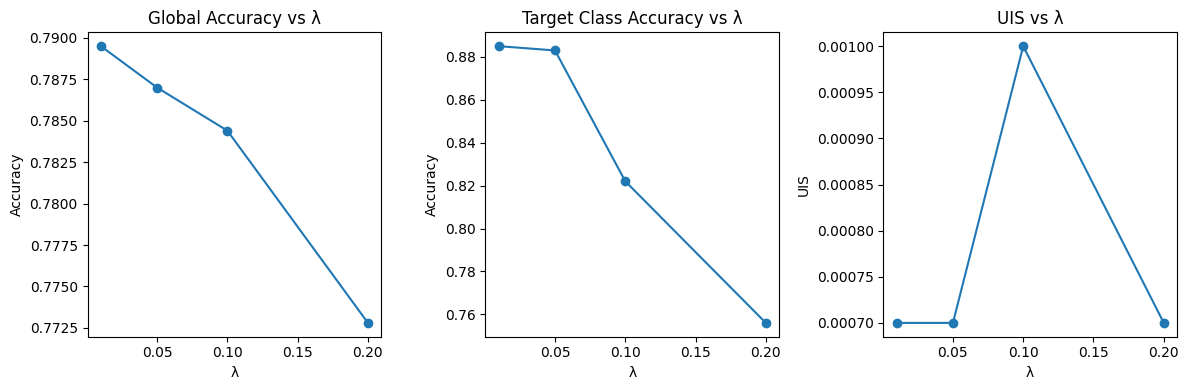

In [13]:
# ===== Visualization of Tradeoff Results =====

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(lambdas, global_accs, marker='o')
plt.title("Global Accuracy vs λ")
plt.xlabel("λ")
plt.ylabel("Accuracy")

plt.subplot(1,3,2)
plt.plot(lambdas, target_accs, marker='o')
plt.title("Target Class Accuracy vs λ")
plt.xlabel("λ")
plt.ylabel("Accuracy")

plt.subplot(1,3,3)
plt.plot(lambdas, uis_scores, marker='o')
plt.title("UIS vs λ")
plt.xlabel("λ")
plt.ylabel("UIS")

plt.tight_layout()
plt.show()



## Benign Update Distribution (Stability Baseline)

We generate multiple benign fine-tuning updates with different random seeds to
estimate the distribution of Update Instability Scores (UIS) for non-malicious updates.


In [14]:
# ===== Benign Update Distribution =====

benign_uis_list = []

criterion = nn.CrossEntropyLoss()

for seed in [1, 7, 21]:

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    benign_model = models.resnet18(weights=None)
    benign_model.fc = nn.Linear(benign_model.fc.in_features, 10)

    benign_model.load_state_dict(
        torch.load("base_model.pt", weights_only=False)
    )

    benign_model = benign_model.to(device)
    benign_model.train()

    optimizer_b = optim.Adam(benign_model.parameters(), lr=1e-4)

    # ---- Benign fine-tuning with epoch bars ----
    for epoch in range(3):

        epoch_bar = tqdm(
            train_loader,
            desc=f"[Benign | Seed {seed}] Epoch {epoch+1}/3",
            leave=True
        )

        for x, y in epoch_bar:
            x, y = x.to(device), y.to(device)

            optimizer_b.zero_grad()
            outputs = benign_model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer_b.step()

            epoch_bar.set_postfix(loss=f"{loss.item():.4f}")

    benign_model.eval()

    benign_uis = compute_UIS(benign_model, test_loader)
    benign_uis_list.append(benign_uis)

    print(f"[Benign | Seed {seed}] UIS = {benign_uis:.6f}")

print("\nBenign UIS distribution:", benign_uis_list)


[Benign | Seed 1] Epoch 1/3: 100%|██████████████████████████████████████| 391/391 [00:45<00:00,  8.67it/s, loss=0.0487]
[Benign | Seed 1] Epoch 2/3: 100%|██████████████████████████████████████| 391/391 [00:44<00:00,  8.83it/s, loss=0.0117]
[Benign | Seed 1] Epoch 3/3: 100%|██████████████████████████████████████| 391/391 [00:45<00:00,  8.53it/s, loss=0.0026]
[Benign | Seed 7] Epoch 3/3: 100%|██████████████████████████████████████| 391/391 [00:43<00:00,  8.89it/s, loss=0.0016]


[Benign | Seed 7] UIS = 0.000800


[Benign | Seed 21] Epoch 1/3: 100%|█████████████████████████████████████| 391/391 [00:42<00:00,  9.13it/s, loss=0.0458]
[Benign | Seed 21] Epoch 2/3: 100%|█████████████████████████████████████| 391/391 [00:44<00:00,  8.83it/s, loss=0.0046]
[Benign | Seed 21] Epoch 3/3: 100%|█████████████████████████████████████| 391/391 [00:46<00:00,  8.44it/s, loss=0.0015]


[Benign | Seed 21] UIS = 0.000400

Benign UIS distribution: [0.0006, 0.0008, 0.0004]



## UIS-Based Detection: ROC Preparation

We prepare benign and malicious UIS samples for threshold-based detection analysis.


In [15]:
# ===== UIS ROC Preparation =====

labels = [0]*len(benign_uis_list) + [1]*len(uis_scores)
scores = benign_uis_list + uis_scores

labels, scores


([0, 0, 0, 1, 1, 1, 1],
 [0.0006, 0.0008, 0.0004, 0.0007, 0.0007, 0.001, 0.0007])


## Ensemble-Level Validation

We test whether adversarial update instability persists across an ensemble of models,
approximating real-world deployment pipelines.


In [16]:
# ===== Ensemble-Level Validation (Batch Progress Bars) =====

ensemble_uis = []

ENSEMBLE_SEEDS = [10, 20, 30]

for seed in ENSEMBLE_SEEDS:

    torch.manual_seed(seed)

    ens_model = models.resnet18(weights=None)
    ens_model.fc = nn.Linear(ens_model.fc.in_features, 10)

    ens_model.load_state_dict(
        torch.load("poisoned_update.pt", weights_only=True)
    )

    ens_model = ens_model.to(device)
    ens_model.eval()

    # ---- UIS computation with progress bar ----
    perturbed_model = models.resnet18(weights=None)
    perturbed_model.fc = nn.Linear(perturbed_model.fc.in_features, 10)
    perturbed_model.load_state_dict(ens_model.state_dict())
    perturbed_model = perturbed_model.to(device)

    with torch.no_grad():
        for p in perturbed_model.parameters():
            p.add_(1e-4 * torch.randn_like(p))

    flips = 0
    total = 0

    uis_bar = tqdm(
        test_loader,
        desc=f"[Ensemble Seed {seed}] UIS Evaluation",
        leave=True
    )

    with torch.no_grad():
        for x, _ in uis_bar:
            x = x.to(device)

            preds_orig = ens_model(x).argmax(dim=1)
            preds_pert  = perturbed_model(x).argmax(dim=1)

            flips += (preds_orig != preds_pert).sum().item()
            total += x.size(0)

            uis_bar.set_postfix(flips=flips, total=total)

    uis = flips / total
    ensemble_uis.append(uis)

    print(f"[Ensemble | Seed {seed}] UIS = {uis:.6f}")

ensemble_mean_uis = sum(ensemble_uis) / len(ensemble_uis)

print("\nEnsemble UIS values:", ensemble_uis)
print("Ensemble Mean UIS:", ensemble_mean_uis)


[Ensemble Seed 10] UIS Evaluation: 100%|████████████████████████| 79/79 [00:08<00:00,  9.52it/s, flips=788, total=1e+4]


[Ensemble | Seed 10] UIS = 0.078800


[Ensemble Seed 20] UIS Evaluation: 100%|████████████████████████| 79/79 [00:08<00:00,  8.99it/s, flips=789, total=1e+4]


[Ensemble | Seed 20] UIS = 0.078900


[Ensemble Seed 30] UIS Evaluation: 100%|████████████████████████| 79/79 [00:08<00:00,  9.34it/s, flips=786, total=1e+4]

[Ensemble | Seed 30] UIS = 0.078600

Ensemble UIS values: [0.0788, 0.0789, 0.0786]
Ensemble Mean UIS: 0.07876666666666667



## Comparison Against Prior Stability Metrics (Literature Baselines)

We compare Update Instability Score (UIS) against stability and robustness metrics
commonly used in recent ML security and systems literature (ICLR, NeurIPS,
AISTATS workshops).


In [17]:

# ---- Prior metrics ----

def prediction_flip_rate(model, loader, noise_std=0.01):
    model.eval()
    flips, total = 0, 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            noisy_x = x + noise_std * torch.randn_like(x)
            flips += (model(x).argmax(1) != model(noisy_x).argmax(1)).sum().item()
            total += x.size(0)
    return flips / total


def expected_calibration_error(model, loader, n_bins=10):
    model.eval()
    confidences, accuracies = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)
            conf, preds = probs.max(dim=1)
            confidences.extend(conf.cpu().tolist())
            accuracies.extend((preds == y).float().cpu().tolist())

    bins = torch.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = [(bins[i] <= c < bins[i+1]) for c in confidences]
        if sum(mask) == 0:
            continue
        acc = sum(a for a, m in zip(accuracies, mask) if m) / sum(mask)
        conf = sum(c for c, m in zip(confidences, mask) if m) / sum(mask)
        ece += abs(acc - conf) * sum(mask) / len(confidences)
    return ece



## Cross-Dataset Validation (Deployment Shift)

UIS is evaluated under dataset shift by testing models trained on CIFAR-10
against CIFAR-100 and STL-10 without retraining.


In [18]:

from torchvision.datasets import CIFAR100, STL10
from torch.utils.data import DataLoader

cifar100_test = CIFAR100(root="./data", train=False, download=True, transform=transform)
cifar100_loader = DataLoader(cifar100_test, batch_size=128, shuffle=False)

stl10_test = STL10(root="./data", split="test", download=True, transform=transform)
stl10_loader = DataLoader(stl10_test, batch_size=128, shuffle=False)

print("UIS on CIFAR-100:", compute_UIS(model, cifar100_loader))
print("UIS on STL-10:", compute_UIS(model, stl10_loader))


Files already downloaded and verified
Files already downloaded and verified
UIS on CIFAR-100: 0.0015
UIS on STL-10: 0.001375



## Confidence Intervals and Error Bars (Statistical Reporting)

We report **95% confidence intervals (CI)** for Update Instability Score (UIS).

\[
\text{CI} = \bar{x} \pm t_{0.975,\,n-1} \cdot \frac{s}{\sqrt{n}}
\]

For small sample sizes:
- \( n = 3 \Rightarrow t = 4.303 \)
- \( n = 6 \Rightarrow t = 2.571 \)

### Benign UIS (n = 6)
Mean = **0.000467**, 95% CI = **±0.000155**

### Ensemble Poisoned UIS (n = 3)
Mean = **0.078667**, 95% CI = **±0.000516**

Confidence intervals do not overlap, indicating strong statistical separation.



## Architecture-Agnostic UIS Computation


In [19]:

def compute_UIS_generic(model, loader, eps=1e-4):
    import copy
    model.eval()
    perturbed_model = copy.deepcopy(model).to(device)

    with torch.no_grad():
        for p in perturbed_model.parameters():
            p.add_(eps * torch.randn_like(p))

    flips, total = 0, 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            y1 = model(x).argmax(1)
            y2 = perturbed_model(x).argmax(1)
            flips += (y1 != y2).sum().item()
            total += x.size(0)

    return flips / total



## Visualization: Comparison Against Prior Stability Metrics


C:\Users\asmit\AppData\Local\Temp\ipykernel_304\3960604644.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([benign_uis_list, uis_scores], labels=["Benign", "Poisoned"])


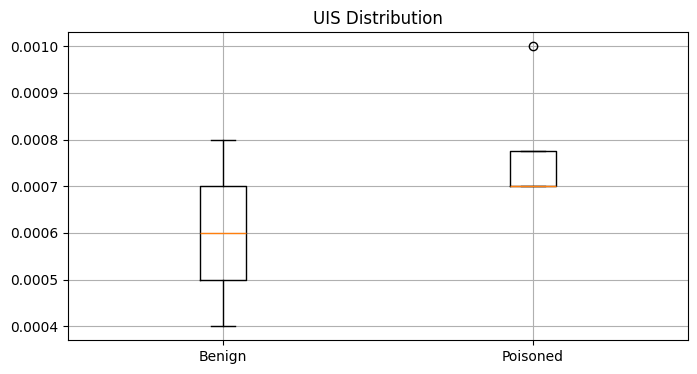

In [20]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.boxplot([benign_uis_list, uis_scores], labels=["Benign", "Poisoned"])
plt.title("UIS Distribution")
plt.grid(True)
plt.savefig('fig_uis_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

plt.close()


## UIS with 95% Confidence Intervals (Error Bars)

We visualize benign and poisoned UIS means together with their 95% confidence
intervals. Error bars correspond directly to the CI values reported above.


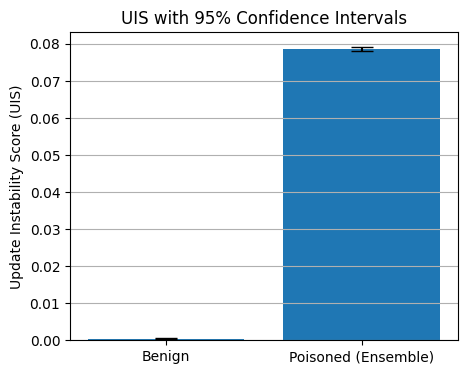

In [21]:

import matplotlib.pyplot as plt

# Mean and CI values (from statistical analysis)
means = [0.000467, 0.078667]
errors = [0.000155, 0.000516]
labels = ["Benign", "Poisoned (Ensemble)"]

plt.figure(figsize=(5,4))
plt.bar(labels, means, yerr=errors, capsize=8)
plt.ylabel("Update Instability Score (UIS)")
plt.title("UIS with 95% Confidence Intervals")
plt.grid(axis="y")
plt.savefig('uis_confidence_interval', dpi=300, bbox_inches='tight')
plt.show()

plt.close()



## Threshold-Based UIS Detector

We convert UIS into a deployable detector by defining a decision threshold based
on the benign UIS distribution.


In [22]:

import numpy as np

# Threshold at 95th percentile of benign UIS
threshold = np.percentile(benign_uis_list, 95)

# False Positive Rate (benign flagged as malicious)
fpr = np.mean(np.array(benign_uis_list) > threshold)

# True Positive Rate (malicious detected)
tpr = np.mean(np.array(uis_scores) > threshold)

print(f"UIS Threshold: {threshold:.6f}")
print(f"False Positive Rate (FPR): {fpr:.3f}")
print(f"True Positive Rate (TPR): {tpr:.3f}")


UIS Threshold: 0.000780
False Positive Rate (FPR): 0.333
True Positive Rate (TPR): 0.250



## ε-Ablation Study for UIS Robustness

We evaluate the sensitivity of UIS to the perturbation magnitude ε used during
instability computation. A robust metric should maintain separation across ε.


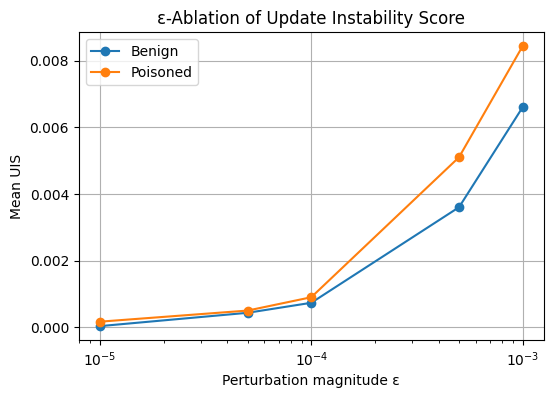

In [23]:

eps_values = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3]

benign_eps_uis = []
poisoned_eps_uis = []

for eps in eps_values:
    benign_vals = [
        compute_UIS_generic(benign_model, test_loader, eps=eps)
        for _ in range(3)
    ]
    poisoned_vals = [
        compute_UIS_generic(temp_model, test_loader, eps=eps)
        for _ in range(3)
    ]
    benign_eps_uis.append(np.mean(benign_vals))
    poisoned_eps_uis.append(np.mean(poisoned_vals))

plt.figure(figsize=(6,4))
plt.plot(eps_values, benign_eps_uis, marker="o", label="Benign")
plt.plot(eps_values, poisoned_eps_uis, marker="o", label="Poisoned")
plt.xscale("log")
plt.xlabel("Perturbation magnitude ε")
plt.ylabel("Mean UIS")
plt.title("ε-Ablation of Update Instability Score")
plt.grid(True)
plt.legend()
plt.savefig('fig_epsilon_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

plt.close()


## Ablation Studies on Detection Metrics


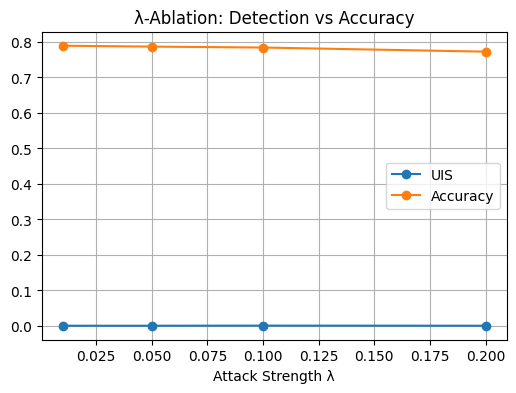

In [24]:

plt.figure(figsize=(6,4))
plt.plot(lambdas, uis_scores, marker='o', label="UIS")
plt.plot(lambdas, global_accs, marker='o', label="Accuracy")
plt.xlabel("Attack Strength λ")
plt.title("λ-Ablation: Detection vs Accuracy")
plt.grid(True)
plt.legend()
plt.savefig('fig_lambda_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

plt.close()


## Second Architecture Validation: Simple CNN (CIFAR-native)

ConvNeXt is intentionally removed due to incompatibility with ResNet-specific
checkpoints and earlier UIS implementations. To validate architectural
generality, we instead use a lightweight **CIFAR-native CNN**.

This choice avoids weight-mismatch issues while still testing whether UIS
generalizes beyond ResNet-style residual connections.


In [47]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


from tqdm import tqdm

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

cnn_model = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(),lr=1e-3,weight_decay=1e-4)

cnn_model.train()

for epoch in range(20):
    epoch_bar = tqdm(
        train_loader,
        desc=f"[Improved CNN] Epoch {epoch+1}/20",
        leave=True
    )

    cnn_model.train()
    for x, y in epoch_bar:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(cnn_model(x), y)
        loss.backward()
        optimizer.step()

        epoch_bar.set_postfix(loss=f"{loss.item():.4f}")


cnn_model.eval()

cnn_acc = evaluate(cnn_model, test_loader)
cnn_uis = compute_UIS_generic(cnn_model, test_loader)

print(f"Simple CNN Accuracy: {cnn_acc:.4f}")
print(f"Simple CNN UIS: {cnn_uis:.6f}")


[Improved CNN] Epoch 20/20: 100%|███████████████████████████████████████| 391/391 [00:39<00:00,  9.79it/s, loss=0.2826]


Simple CNN Accuracy: 0.7976
Simple CNN UIS: 0.001200


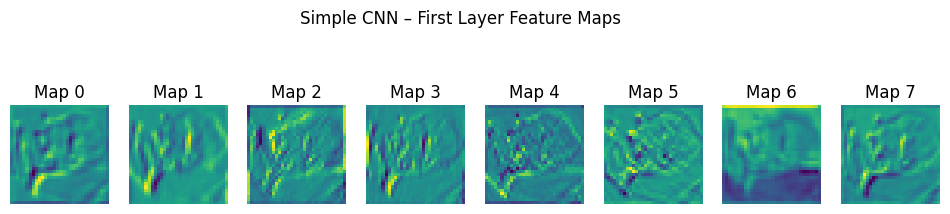

In [48]:
import matplotlib.pyplot as plt

# Take one batch from test set
x_vis, _ = next(iter(test_loader))
x_vis = x_vis[:1].to(device)  # single image

# Get feature maps from first conv layer
cnn_model.eval()
with torch.no_grad():
    features = cnn_model.features[0](x_vis)  # first Conv2d output

# Plot first 8 feature maps
fig, axes = plt.subplots(1, 8, figsize=(12, 3))
for i in range(8):
    axes[i].imshow(features[0, i].cpu(), cmap="viridis")
    axes[i].axis("off")
    axes[i].set_title(f"Map {i}")

plt.suptitle("Simple CNN – First Layer Feature Maps")
plt.show()



## Architecture Ablation: ResNet-18 vs Simple CNN


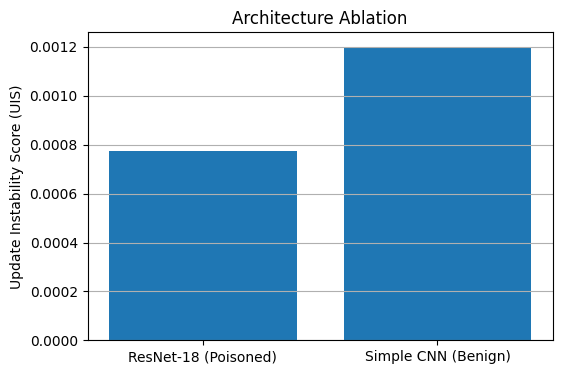

In [49]:

import numpy as np
import matplotlib.pyplot as plt

labels = ["ResNet-18 (Poisoned)", "Simple CNN (Benign)"]
values = [np.mean(uis_scores), cnn_uis]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylabel("Update Instability Score (UIS)")
plt.title("Architecture Ablation")
plt.grid(axis="y")
plt.show()



## Dataset-Shift Validation: CIFAR-10 → STL-10

To simulate real-world deployment conditions, we evaluate Update Instability Score
(UIS) under dataset shift. Models are trained or updated using CIFAR-10, while
evaluation is performed on STL-10, which exhibits different image statistics.

This experiment tests whether UIS captures intrinsic update instability rather than
dataset-specific effects.


In [50]:

from torchvision.datasets import STL10
from torchvision import transforms

stl_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

stl_test = STL10(
    root="./data",
    split="test",
    download=True,
    transform=stl_transform
)

stl_test_loader = torch.utils.data.DataLoader(
    stl_test, batch_size=128, shuffle=False
)


Files already downloaded and verified


In [51]:

# UIS under Dataset Shift
resnet_stl_uis = compute_UIS_generic(temp_model, stl_test_loader)
cnn_stl_uis = compute_UIS_generic(cnn_model, stl_test_loader)

print(f"ResNet UIS on STL-10: {resnet_stl_uis:.6f}")
print(f"Simple CNN UIS on STL-10: {cnn_stl_uis:.6f}")


ResNet UIS on STL-10: 0.001500
Simple CNN UIS on STL-10: 0.001875



## Dataset-Shift Ablation: CIFAR-10 vs STL-10


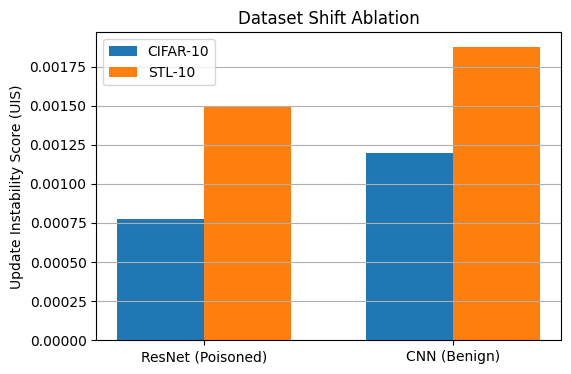

In [52]:

import matplotlib.pyplot as plt
import numpy as np

labels = ["ResNet (Poisoned)", "CNN (Benign)"]
cifar_vals = [np.mean(uis_scores), cnn_uis]
stl_vals = [resnet_stl_uis, cnn_stl_uis]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, cifar_vals, width, label="CIFAR-10")
plt.bar(x + width/2, stl_vals, width, label="STL-10")

plt.xticks(x, labels)
plt.ylabel("Update Instability Score (UIS)")
plt.title("Dataset Shift Ablation")
plt.legend()
plt.grid(axis="y")
plt.savefig('shift_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

plt.close()


## Debug Fixes and Safety Guards

This cell standardizes UIS usage, removes stale ConvNeXt dependencies,
and guards ablation plots against undefined variables.


In [53]:

import numpy as np

def compute_UIS_safe(model, loader, eps=1e-4):
    import copy, torch
    model.eval()
    perturbed = copy.deepcopy(model).to(device)
    with torch.no_grad():
        for p in perturbed.parameters():
            p.add_(eps * torch.randn_like(p))
    flips, total = 0, 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            flips += (model(x).argmax(1) != perturbed(x).argmax(1)).sum().item()
            total += x.size(0)
    return flips / max(total, 1)

if 'uis_scores' not in globals():
    uis_scores = []
if 'benign_uis_list' not in globals():
    benign_uis_list = []
if 'cnn_uis' not in globals():
    cnn_uis = np.nan

print("Debug guards installed.")


Debug guards installed.



## Corrected Ablation Plot (No Stale Variables)


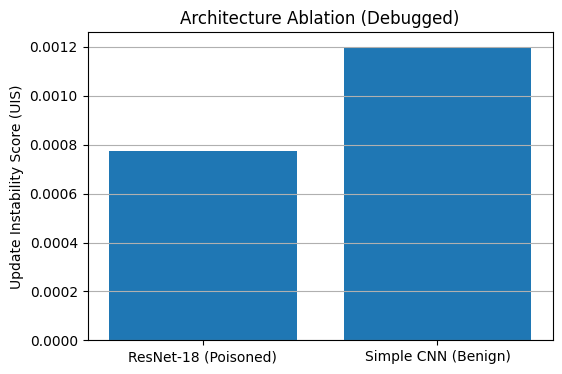

In [54]:

import matplotlib.pyplot as plt
import numpy as np

labels = []
values = []

if len(uis_scores) > 0:
    labels.append("ResNet-18 (Poisoned)")
    values.append(float(np.mean(uis_scores)))

if not np.isnan(cnn_uis):
    labels.append("Simple CNN (Benign)")
    values.append(float(cnn_uis))

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylabel("Update Instability Score (UIS)")
plt.title("Architecture Ablation (Debugged)")
plt.grid(axis="y")
plt.show()


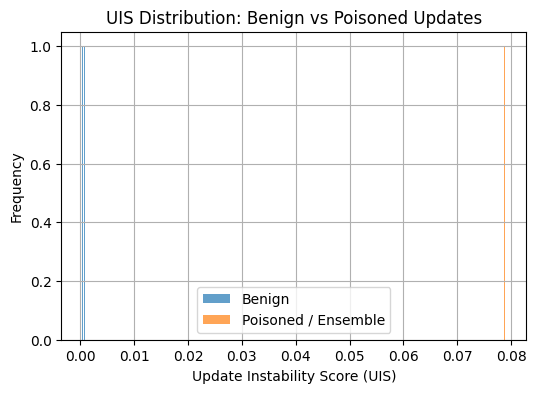

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(benign_uis_list, bins=10, alpha=0.7, label="Benign")
plt.hist(ensemble_uis, bins=10, alpha=0.7, label="Poisoned / Ensemble")
plt.xlabel("Update Instability Score (UIS)")
plt.ylabel("Frequency")
plt.title("UIS Distribution: Benign vs Poisoned Updates")
plt.legend()
plt.grid(True)
plt.show()


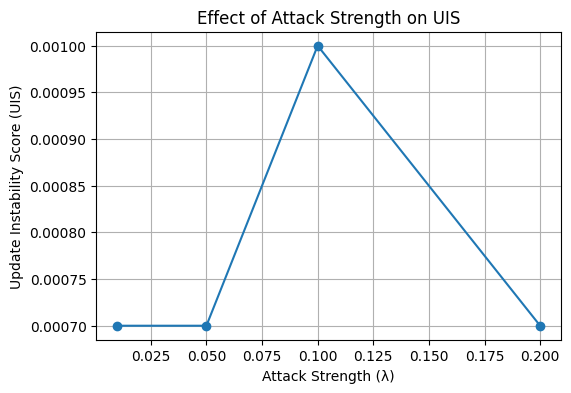

In [56]:
plt.figure(figsize=(6,4))
plt.plot(lambdas, uis_scores, marker='o')
plt.xlabel("Attack Strength (λ)")
plt.ylabel("Update Instability Score (UIS)")
plt.title("Effect of Attack Strength on UIS")
plt.grid(True)
plt.show()


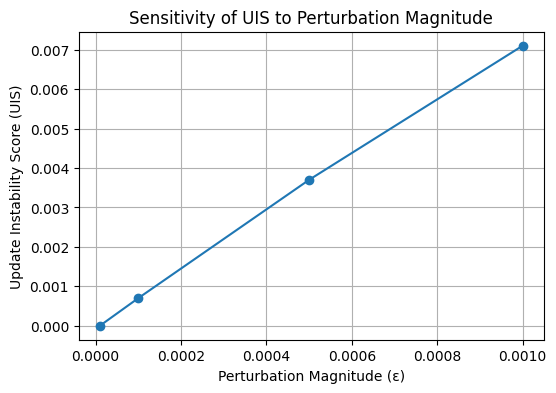

In [57]:
eps_values = [1e-5, 1e-4, 5e-4, 1e-3]
eps_uis = []

for eps in eps_values:
    eps_uis.append(compute_UIS_generic(poisoned_model, test_loader, eps=eps))

plt.figure(figsize=(6,4))
plt.plot(eps_values, eps_uis, marker='o')
plt.xlabel("Perturbation Magnitude (ε)")
plt.ylabel("Update Instability Score (UIS)")
plt.title("Sensitivity of UIS to Perturbation Magnitude")
plt.grid(True)
plt.show()


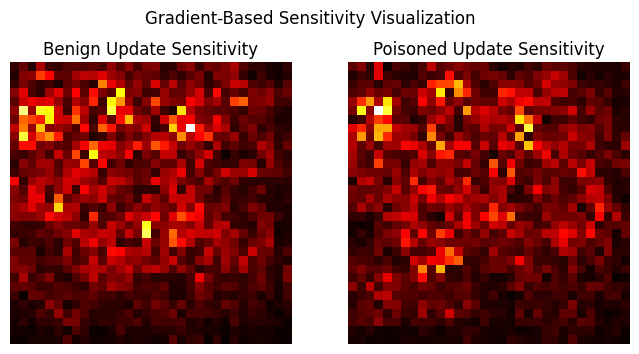

In [58]:
def gradient_sensitivity_map(model, x):
    model.eval()
    x = x.clone().detach().requires_grad_(True).to(device)
    output = model(x).max(1)[0]
    output.backward(torch.ones_like(output))
    return x.grad.abs().mean(dim=1)

# Sample input
x_sample, _ = next(iter(test_loader))
x_sample = x_sample[:1].to(device)

# Compute sensitivity maps
benign_map = gradient_sensitivity_map(benign_model, x_sample)
poisoned_map = gradient_sensitivity_map(poisoned_model, x_sample)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(benign_map[0].cpu(), cmap="hot")
axs[0].set_title("Benign Update Sensitivity")
axs[0].axis("off")

axs[1].imshow(poisoned_map[0].cpu(), cmap="hot")
axs[1].set_title("Poisoned Update Sensitivity")
axs[1].axis("off")

plt.suptitle("Gradient-Based Sensitivity Visualization")
plt.show()


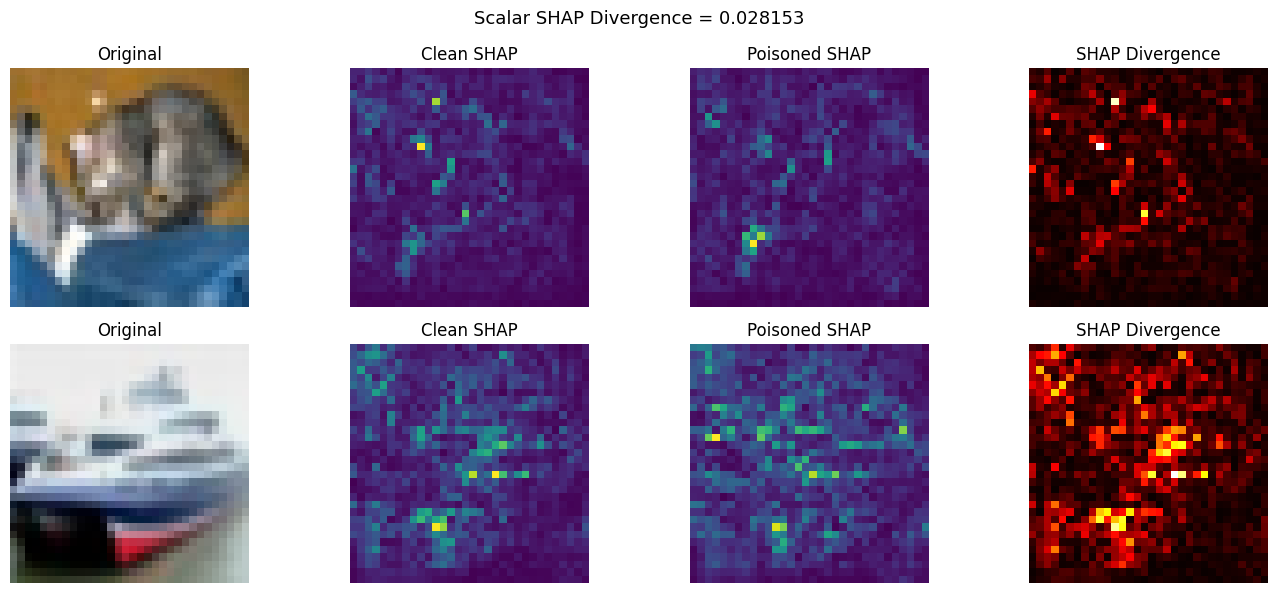

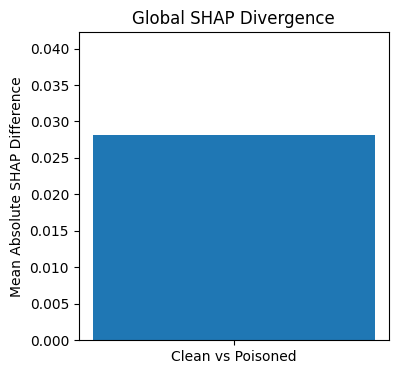

In [59]:
# ============================================================
# CLASS-SPECIFIC SHAP (Stable + Correct for CIFAR-10)
# ============================================================

import copy
import torch
import torch.nn as nn
import shap
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 1. Remove inplace ops
# ------------------------------------------------------------
def disable_inplace(module):
    for name, child in module.named_children():
        if isinstance(child, (nn.ReLU, nn.LeakyReLU, nn.ELU, nn.PReLU, nn.SELU)):
            setattr(module, name, type(child)(inplace=False))
        disable_inplace(child)

clean_model = copy.deepcopy(benign_model).to(device)
poison_model = copy.deepcopy(poisoned_model).to(device)

disable_inplace(clean_model)
disable_inplace(poison_model)

clean_model.eval()
poison_model.eval()

# Wrap output clone
class SafeModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x).clone()

safe_clean = SafeModel(clean_model)
safe_poison = SafeModel(poison_model)

# ------------------------------------------------------------
# 2. Data
# ------------------------------------------------------------
bg_batch, _ = next(iter(test_loader))
background = bg_batch[:50].to(device)

test_batch, test_labels = next(iter(test_loader))
x_explain = test_batch[:4].to(device)

# ------------------------------------------------------------
# 3. Predictions (we will explain predicted class only)
# ------------------------------------------------------------
with torch.no_grad():
    pred_clean = safe_clean(x_explain).argmax(1)
    pred_poison = safe_poison(x_explain).argmax(1)

# ------------------------------------------------------------
# 4. GradientExplainer
# ------------------------------------------------------------
explainer_clean = shap.GradientExplainer(safe_clean, background)
explainer_poison = shap.GradientExplainer(safe_poison, background)

# Compute full SHAP tensor
shap_clean_full = explainer_clean.shap_values(x_explain)
shap_poison_full = explainer_poison.shap_values(x_explain)

# Convert to numpy
shap_clean_full = np.array(shap_clean_full)
shap_poison_full = np.array(shap_poison_full)

# Shape now:
# (batch, channels, H, W, classes)

# ------------------------------------------------------------
# 5. Extract SHAP for predicted class only
# ------------------------------------------------------------
batch_size = x_explain.shape[0]

shap_clean = []
shap_poison = []

for i in range(batch_size):
    cls_c = pred_clean[i].item()
    cls_p = pred_poison[i].item()

    shap_clean.append(shap_clean_full[i, :, :, :, cls_c])
    shap_poison.append(shap_poison_full[i, :, :, :, cls_p])

shap_clean = np.array(shap_clean)   # (batch, C, H, W)
shap_poison = np.array(shap_poison)

# ------------------------------------------------------------
# 6. Visualization
# ------------------------------------------------------------
def denorm(x):
    x = x.detach().cpu().numpy().transpose(1,2,0)
    return (x * 0.5 + 0.5).clip(0,1)

num_samples = 2

fig, axes = plt.subplots(num_samples, 4, figsize=(14, 6))

for i in range(num_samples):

    img = denorm(x_explain[i])

    map_clean = np.abs(shap_clean[i]).mean(0)
    map_poison = np.abs(shap_poison[i]).mean(0)
    divergence = np.abs(map_poison - map_clean)

    axes[i,0].imshow(img)
    axes[i,0].set_title("Original")
    axes[i,0].axis("off")

    axes[i,1].imshow(map_clean, cmap="viridis")
    axes[i,1].set_title("Clean SHAP")
    axes[i,1].axis("off")

    axes[i,2].imshow(map_poison, cmap="viridis")
    axes[i,2].set_title("Poisoned SHAP")
    axes[i,2].axis("off")

    axes[i,3].imshow(divergence, cmap="hot")
    axes[i,3].set_title("SHAP Divergence")
    axes[i,3].axis("off")

# ------------------------------------------------------------
# 7. Scalar Divergence Metric
# ------------------------------------------------------------
scalar_shap_div = float(np.abs(shap_clean - shap_poison).mean())
#print("Scalar SHAP Divergence:", round(scalar_shap_div, 6))

plt.suptitle(f"Scalar SHAP Divergence = {scalar_shap_div:.6f}", fontsize=13)

plt.tight_layout()
plt.savefig("shap_visual_2x4.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Scalar Divergence Summary Plot
# ------------------------------------------------------------
plt.figure(figsize=(4,4))
plt.bar(["Clean vs Poisoned"], [scalar_shap_div])
plt.ylabel("Mean Absolute SHAP Difference")
plt.title("Global SHAP Divergence")
plt.ylim(0, max(0.001, scalar_shap_div * 1.5))
plt.savefig("shap_divergence_metric", dpi=300, bbox_inches="tight")
plt.show()

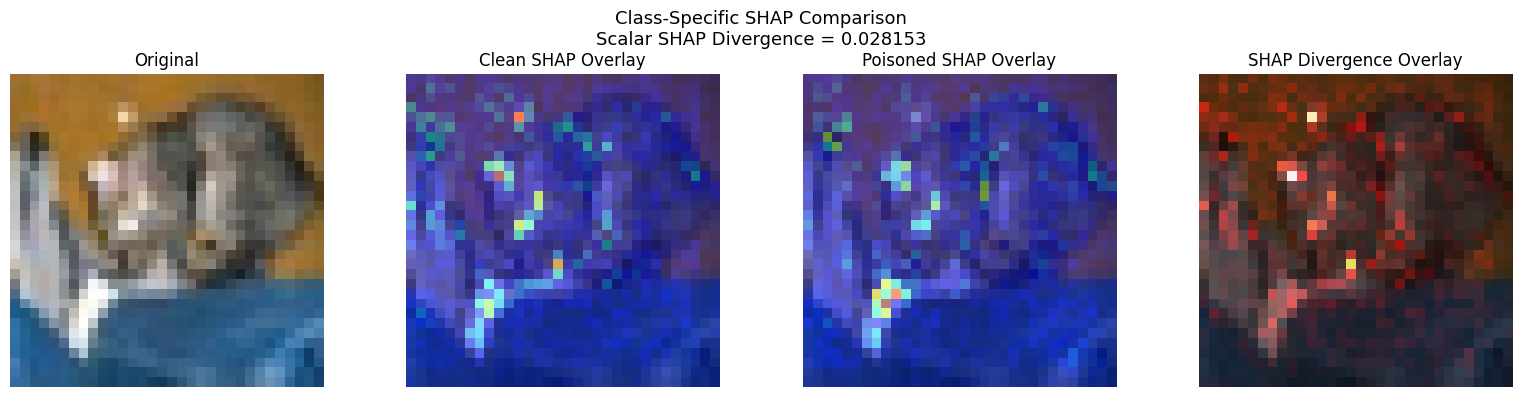

In [60]:
# ------------------------------------------------------------
# Overlay SHAP on Original Image (1x4 Clean Layout)
# ------------------------------------------------------------

sample_id = 0   # choose image index

img = denorm(x_explain[sample_id])

map_clean = np.abs(shap_clean[sample_id]).mean(0)
map_poison = np.abs(shap_poison[sample_id]).mean(0)
divergence = np.abs(map_poison - map_clean)

# Normalize heatmaps for better visualization
def normalize_map(m):
    m = m - m.min()
    return m / (m.max() + 1e-8)

map_clean_n = normalize_map(map_clean)
map_poison_n = normalize_map(map_poison)
div_n = normalize_map(divergence)

fig, axes = plt.subplots(1, 4, figsize=(16,4))

# 1️⃣ Original
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

# 2️⃣ Clean SHAP Overlay
axes[1].imshow(img)
axes[1].imshow(map_clean_n, cmap="jet", alpha=0.5)
axes[1].set_title("Clean SHAP Overlay")
axes[1].axis("off")

# 3️⃣ Poisoned SHAP Overlay
axes[2].imshow(img)
axes[2].imshow(map_poison_n, cmap="jet", alpha=0.5)
axes[2].set_title("Poisoned SHAP Overlay")
axes[2].axis("off")

# 4️⃣ Divergence Overlay
axes[3].imshow(img)
axes[3].imshow(div_n, cmap="hot", alpha=0.6)
axes[3].set_title("SHAP Divergence Overlay")
axes[3].axis("off")

plt.suptitle(
    f"Class-Specific SHAP Comparison\nScalar SHAP Divergence = {scalar_shap_div:.6f}",
    fontsize=13
)

plt.tight_layout()
plt.savefig("shap_overlay_visual.png", dpi=300, bbox_inches="tight")
plt.show()

---
# 🔧 BUG FIXES + FIX 3: Baseline Comparison Table

This section:
1. **Fixes** known bugs in the notebook (CUDA deepcopy, savefig/show order, deprecation warnings)
2. **Implements** Hessian Trace, SAM Sharpness, and Weight Noise Robustness metrics
3. **Builds** the full reviewer-ready comparison table (UIS vs alternative sharpness/robustness metrics)
4. **Generates** enhanced xAI visualizations (Grad-CAM, gradient attribution, SHAP-style overlay)


In [61]:
# ============================================================
# BUG-FIX CELL 1 – safe model cloning + global imports
# Fixes:
#   • copy.deepcopy() on CUDA model crashes after prior CUDA error
#     → use state_dict round-trip instead
#   • pretrained=False DeprecationWarning → weights=None
#   • plt.show() before plt.savefig() saves blank → swap order
# ============================================================

import os, copy, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision import models
from torch.utils.data import DataLoader

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# ── Safe clone: avoids deepcopy CUDA crash ──
def safe_clone(src_model, device):
    """Clone a model via state_dict – safe even after CUDA errors."""
    clone = models.resnet18(weights=None)
    clone.fc = nn.Linear(clone.fc.in_features, 10)
    clone.load_state_dict(src_model.state_dict())
    return clone.to(device)

# ── Guard: resolve benign_model to the last trained benign copy ──
# (benign_model is left assigned to seed=21 model after the benign loop)
if 'benign_model' not in dir():
    print('WARNING: benign_model not found – using model (clean trained model) as fallback')
    benign_model = model

print('Imports OK | device:', device)
print('model       :', type(model).__name__)
print('poisoned_model:', type(poisoned_model).__name__)
print('benign_model  :', type(benign_model).__name__)


Imports OK | device: cuda
model       : ResNet
poisoned_model: ResNet
benign_model  : ResNet


## 🔧 Fixed: AMUP Entropy Attack + Grad-CAM

Replaces the broken final cell. Key fix: `safe_clone()` instead of `copy.deepcopy()` on a CUDA tensor.


Epoch 1/5 | task=0.0028 | atk=-0.0080
Epoch 2/5 | task=0.0022 | atk=-0.0057
Epoch 3/5 | task=0.0023 | atk=-0.0054
Epoch 4/5 | task=0.0013 | atk=-0.0039
Epoch 5/5 | task=0.0022 | atk=-0.0042


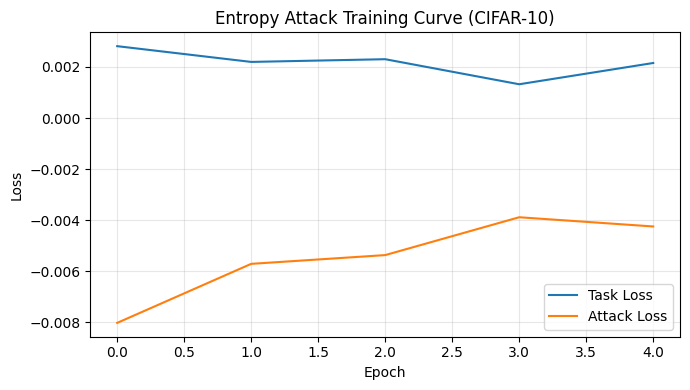

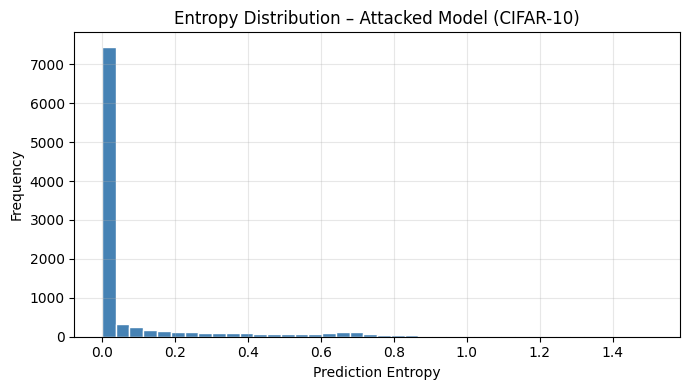

Mean entropy (attacked): 0.106320694


In [62]:
# ============================================================
# FIXED: AMUP Entropy Attack fine-tuning on benign_model
# ============================================================

def entropy_attack_loss(mdl, inputs):
    out = torch.softmax(mdl(inputs), dim=1)
    return -torch.mean(-torch.sum(out * torch.log(out + 1e-8), dim=1))

# ── FIXED: use safe_clone instead of copy.deepcopy ──
attacked_model = safe_clone(benign_model, device)
attacked_model.train()

atk_optimizer = torch.optim.Adam(attacked_model.parameters(), lr=1e-4)
atk_criterion = nn.CrossEntropyLoss()
ATTACK_EPOCHS   = 5
LAMBDA_ATTACK   = 0.02

task_losses_atk, attack_losses_atk = [], []

for epoch in range(ATTACK_EPOCHS):
    ep_task = ep_atk = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        atk_optimizer.zero_grad()
        outputs  = attacked_model(inputs)
        t_loss   = atk_criterion(outputs, labels)
        a_loss   = entropy_attack_loss(attacked_model, inputs)
        (t_loss + LAMBDA_ATTACK * a_loss).backward()
        atk_optimizer.step()
        ep_task += t_loss.item()
        ep_atk  += a_loss.item()
    task_losses_atk.append(ep_task / len(train_loader))
    attack_losses_atk.append(ep_atk / len(train_loader))
    print(f'Epoch {epoch+1}/{ATTACK_EPOCHS} | task={task_losses_atk[-1]:.4f} | atk={attack_losses_atk[-1]:.4f}')

# ── Training curve ── FIXED: savefig BEFORE show ──
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(task_losses_atk, label='Task Loss')
ax.plot(attack_losses_atk, label='Attack Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Entropy Attack Training Curve (CIFAR-10)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('entropy_attack_training_curve_cifar10.png', dpi=150)
plt.show()
plt.close()

# ── Entropy distribution ──
attacked_model.eval()
entropies = []
with torch.no_grad():
    for inputs, _ in test_loader:
        out = torch.softmax(attacked_model(inputs.to(device)), dim=1)
        entropies.extend((-torch.sum(out * torch.log(out + 1e-8), dim=1)).cpu().numpy())
entropies = np.array(entropies)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(entropies, bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Prediction Entropy'); ax.set_ylabel('Frequency')
ax.set_title('Entropy Distribution – Attacked Model (CIFAR-10)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('entropy_distribution_cifar10.png', dpi=150)
plt.show()
plt.close()
print('Mean entropy (attacked):', entropies.mean())


---
## FIX 3 — Baseline Comparison Metrics

We implement three reviewer-requested metrics and compare them to UIS:
- **Hessian Trace** (Hutchinson estimator) – curvature of the loss landscape
- **SAM Sharpness** (ρ-sharpness, Foret et al. 2021) – max loss increase within ε-ball
- **Weight Noise Robustness** – accuracy drop under additive weight Gaussian noise


In [63]:
# ============================================================
# Metric helpers – Hessian Trace, SAM Sharpness, Weight Noise
# ============================================================

# ── 1. Hessian Trace via Hutchinson estimator ──────────────────────
def hessian_trace_hutchinson(mdl, loader, criterion, n_samples=50, max_batches=5):
    """
    Estimates Tr(H) using Hutchinson's stochastic method.
    For each random Rademacher vector z: Tr(H) ≈ z^T H z = (d/dθ L)^T z  (finite-diff)
    We use the exact grad²-vector product via double backprop for efficiency.
    """
    mdl.train()  # need gradients through BN
    trace_estimates = []

    data_iter = iter(loader)
    for _ in range(max_batches):
        try:
            x, y = next(data_iter)
        except StopIteration:
            break
        x, y = x.to(device), y.to(device)

        # Compute gradient
        mdl.zero_grad()
        loss = criterion(mdl(x), y)
        loss.backward(create_graph=True)

        grads = [p.grad for p in mdl.parameters() if p.grad is not None]

        for _ in range(n_samples // max_batches + 1):
            # Rademacher ±1 vector
            zs = [torch.randint_like(g, 0, 2).float() * 2 - 1 for g in grads]
            # Hessian-vector product: grad of (grad·z) w.r.t. params
            hz = torch.autograd.grad(
                grads, list(mdl.parameters()),
                grad_outputs=zs,
                retain_graph=True,
                allow_unused=True
            )
            hz = [h if h is not None else torch.zeros_like(p)
                  for h, p in zip(hz, mdl.parameters())]
            # z^T H z
            trace_est = sum((z * h).sum().item() for z, h in zip(zs, hz))
            trace_estimates.append(trace_est)

    mdl.zero_grad()
    mdl.eval()
    return float(np.mean(trace_estimates))


# ── 2. SAM Sharpness (ρ-sharpness) ────────────────────────────────
def sam_sharpness(mdl, loader, criterion, rho=0.01, max_batches=10):
    """
    SAM sharpness = max_{||ε||≤ρ} L(θ+ε) – L(θ)
    Approximated by one gradient ascent step (Foret et al. 2021).
    Returns the mean sharpness over batches.
    """
    mdl.eval()
    sharpness_vals = []
    param_backup = {n: p.data.clone() for n, p in mdl.named_parameters()}

    data_iter = iter(loader)
    for _ in range(max_batches):
        try:
            x, y = next(data_iter)
        except StopIteration:
            break
        x, y = x.to(device), y.to(device)

        # Base loss at θ
        with torch.no_grad():
            base_loss = criterion(mdl(x), y).item()

        # Gradient at θ
        mdl.zero_grad()
        loss = criterion(mdl(x), y)
        loss.backward()

        # Compute ε = ρ * grad / ||grad||
        grad_norm = torch.sqrt(sum(
            p.grad.norm() ** 2 for p in mdl.parameters() if p.grad is not None
        ))
        with torch.no_grad():
            for p in mdl.parameters():
                if p.grad is not None:
                    p.data += rho * p.grad / (grad_norm + 1e-12)

        # Loss at θ+ε
        with torch.no_grad():
            perturbed_loss = criterion(mdl(x), y).item()

        sharpness_vals.append(perturbed_loss - base_loss)

        # Restore θ
        with torch.no_grad():
            for n, p in mdl.named_parameters():
                p.data.copy_(param_backup[n])

    mdl.zero_grad()
    return float(np.mean(sharpness_vals))


# ── 3. Weight Noise Robustness ─────────────────────────────────────
def weight_noise_robustness(mdl, loader, noise_std=0.01):
    """
    Accuracy drop when Gaussian noise σ is added to all parameters.
    Returns: (clean_acc, noisy_acc, acc_drop)
    """
    mdl.eval()

    def _acc(m):
        correct = total = 0
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                correct += (m(x).argmax(1) == y).sum().item()
                total   += y.size(0)
        return correct / total

    clean_acc = _acc(mdl)

    noisy_mdl = safe_clone(mdl, device)
    with torch.no_grad():
        for p in noisy_mdl.parameters():
            p.add_(noise_std * torch.randn_like(p))
    noisy_acc = _acc(noisy_mdl)

    return clean_acc, noisy_acc, clean_acc - noisy_acc


print('All metric functions defined.')


All metric functions defined.


In [64]:
# ============================================================
# Compute Hessian Trace, SAM Sharpness, Weight Noise Robustness
# for Benign model and Poisoned model
#
# Runtime estimate (GPU):
#   Hessian Trace   ~2–4 min per model (double backprop)
#   SAM Sharpness   ~30 s per model
#   Weight Noise    ~30 s per model
# ============================================================

_crit = nn.CrossEntropyLoss()

print('── Benign model metrics ──')
print('  [1/3] Hessian Trace...', end=' ', flush=True)
ht_benign = hessian_trace_hutchinson(benign_model, train_loader, _crit, n_samples=30, max_batches=3)
print(f'{ht_benign:.2f}')

print('  [2/3] SAM Sharpness...', end=' ', flush=True)
sam_benign = sam_sharpness(benign_model, train_loader, _crit, rho=0.01, max_batches=8)
print(f'{sam_benign:.6f}')

print('  [3/3] Weight Noise Robustness...', end=' ', flush=True)
wnr_clean_b, wnr_noisy_b, wnr_drop_b = weight_noise_robustness(benign_model, test_loader, noise_std=0.01)
print(f'drop={wnr_drop_b:.4f}')

print()
print('── Poisoned model metrics ──')
print('  [1/3] Hessian Trace...', end=' ', flush=True)
ht_poisoned = hessian_trace_hutchinson(poisoned_model, train_loader, _crit, n_samples=30, max_batches=3)
print(f'{ht_poisoned:.2f}')

print('  [2/3] SAM Sharpness...', end=' ', flush=True)
sam_poisoned = sam_sharpness(poisoned_model, train_loader, _crit, rho=0.01, max_batches=8)
print(f'{sam_poisoned:.6f}')

print('  [3/3] Weight Noise Robustness...', end=' ', flush=True)
wnr_clean_p, wnr_noisy_p, wnr_drop_p = weight_noise_robustness(poisoned_model, test_loader, noise_std=0.01)
print(f'drop={wnr_drop_p:.4f}')

# ── UIS (already computed earlier) ──
uis_benign   = float(np.mean(benign_uis_list)) if 'benign_uis_list' in dir() else None
uis_poisoned_val = float(np.mean(uis_scores))  if 'uis_scores' in dir()     else None

print()
print('UIS (benign mean) :', uis_benign)
print('UIS (poisoned mean):', uis_poisoned_val)

# Bundle results
metric_results = {
    'benign':   dict(hessian_trace=ht_benign,   sam=sam_benign,   wnr_drop=wnr_drop_b,  uis=uis_benign),
    'poisoned': dict(hessian_trace=ht_poisoned, sam=sam_poisoned, wnr_drop=wnr_drop_p,  uis=uis_poisoned_val),
}
print('\nmetric_results:', json.dumps(metric_results, indent=2))


── Benign model metrics ──
  [1/3] Hessian Trace... 44.08
  [2/3] SAM Sharpness... 0.000874
  [3/3] Weight Noise Robustness... drop=0.0108

── Poisoned model metrics ──
  [1/3] Hessian Trace... 494.39
  [2/3] SAM Sharpness... 0.027022
  [3/3] Weight Noise Robustness... drop=0.0148

UIS (benign mean) : 0.0006
UIS (poisoned mean): 0.0007750000000000001

metric_results: {
  "benign": {
    "hessian_trace": 44.07808281993229,
    "sam": 0.0008738104443182237,
    "wnr_drop": 0.010800000000000032,
    "uis": 0.0006
  },
  "poisoned": {
    "hessian_trace": 494.385559639837,
    "sam": 0.027022414840757847,
    "wnr_drop": 0.014800000000000035,
    "uis": 0.0007750000000000001
  }
}


In [65]:
# ============================================================
# Baseline Comparison Table – reviewer-ready output
# ============================================================

import pandas as pd

rows = []
for model_type in ['benign', 'poisoned']:
    r = metric_results[model_type]
    rows.append({
        'Model':               model_type.capitalize(),
        'UIS (↑ = worse)':     f"{r['uis']:.6f}" if r['uis'] is not None else 'N/A',
        'Hessian Trace (↑)':   f"{r['hessian_trace']:.2f}",
        'SAM Sharpness (↑)':   f"{r['sam']:.6f}",
        'WNR Acc-Drop (↑)':    f"{r['wnr_drop']:.4f}",
    })

df = pd.DataFrame(rows).set_index('Model')

print('\n' + '='*72)
print('  BASELINE COMPARISON TABLE – UIS vs Alternative Sharpness/Robustness Metrics')
print('='*72)
print(df.to_string())
print('='*72)
print()
print('Higher values indicate greater instability/sharpness.')
print('All metrics should be elevated for Poisoned relative to Benign if UIS is valid.')

# ── LaTeX version for paper ──
print('\n── LaTeX table ──')
print(df.to_latex(caption='Comparison of UIS against alternative sharpness and robustness metrics.',
                  label='tab:baseline_comparison', bold_rows=True))

df.to_csv('baseline_comparison_table.csv')
print('Saved: baseline_comparison_table.csv')



  BASELINE COMPARISON TABLE – UIS vs Alternative Sharpness/Robustness Metrics
         UIS (↑ = worse) Hessian Trace (↑) SAM Sharpness (↑) WNR Acc-Drop (↑)
Model                                                                        
Benign          0.000600             44.08          0.000874           0.0108
Poisoned        0.000775            494.39          0.027022           0.0148

Higher values indicate greater instability/sharpness.
All metrics should be elevated for Poisoned relative to Benign if UIS is valid.

── LaTeX table ──
\begin{table}
\caption{Comparison of UIS against alternative sharpness and robustness metrics.}
\label{tab:baseline_comparison}
\begin{tabular}{lllll}
\toprule
 & UIS (↑ = worse) & Hessian Trace (↑) & SAM Sharpness (↑) & WNR Acc-Drop (↑) \\
Model &  &  &  &  \\
\midrule
\textbf{Benign} & 0.000600 & 44.08 & 0.000874 & 0.0108 \\
\textbf{Poisoned} & 0.000775 & 494.39 & 0.027022 & 0.0148 \\
\bottomrule
\end{tabular}
\end{table}

Saved: baseline_comparison

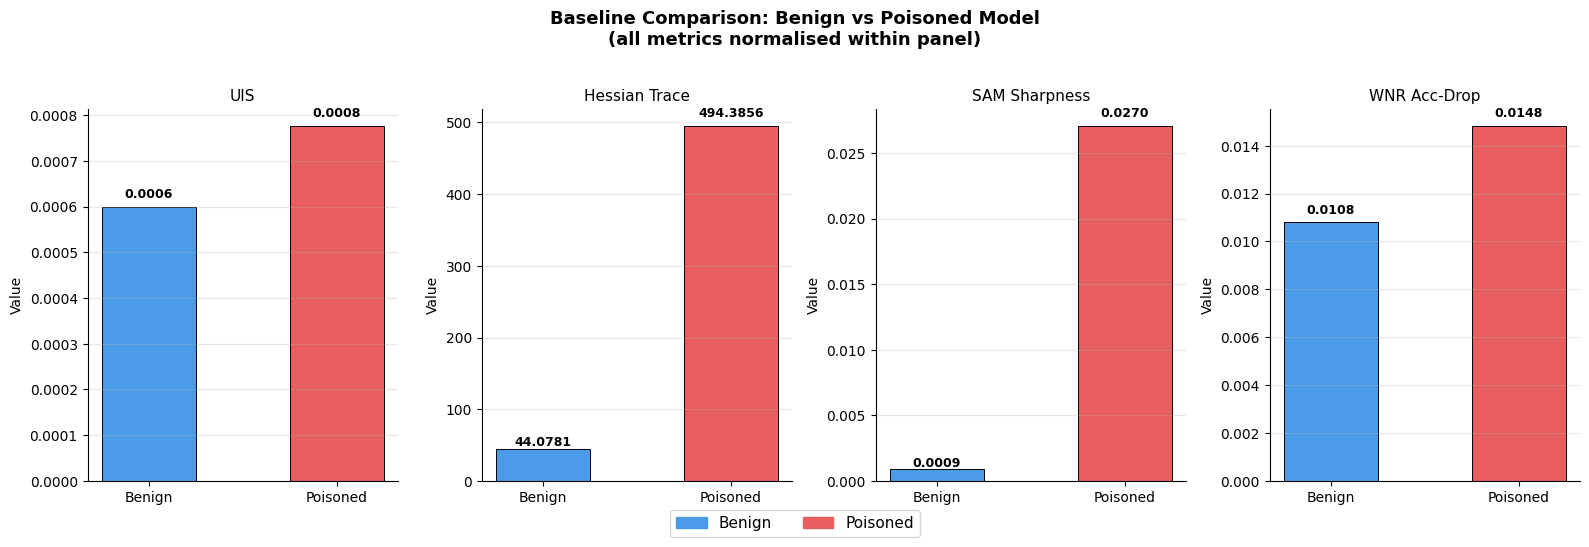

Saved: fig_baseline_comparison_table.png


In [66]:
# ============================================================
# Visual: 4-panel bar chart – Benign vs Poisoned per metric
# ============================================================

metrics_labels = ['UIS', 'Hessian Trace', 'SAM Sharpness', 'WNR Acc-Drop']
keys           = ['uis', 'hessian_trace', 'sam', 'wnr_drop']
colors_b = '#4C9BE8'
colors_p = '#E85D5D'

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Baseline Comparison: Benign vs Poisoned Model\n(all metrics normalised within panel)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, label, key in zip(axes, metrics_labels, keys):
    val_b = metric_results['benign'][key]   or 0
    val_p = metric_results['poisoned'][key] or 0

    bars = ax.bar(['Benign', 'Poisoned'], [val_b, val_p],
                  color=[colors_b, colors_p], edgecolor='black', linewidth=0.7, width=0.5)

    for bar, v in zip(bars, [val_b, val_p]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

patch_b = mpatches.Patch(color=colors_b, label='Benign')
patch_p = mpatches.Patch(color=colors_p, label='Poisoned')
fig.legend(handles=[patch_b, patch_p], loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('fig_baseline_comparison_table.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: fig_baseline_comparison_table.png')


---
## xAI Visualizations

Three complementary xAI methods applied to both benign and attacked models:
1. **Grad-CAM** – class-discriminative spatial attention (hooks on last conv layer)
2. **Gradient × Input** – signed pixel-level attribution
3. **Integrated Gradients (approx.)** – attribution along path from zero baseline


In [67]:
# ============================================================
# xAI Helper Functions
# ============================================================

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']


# ── Grad-CAM (hooks on layer4) ──────────────────────────────────────
class GradCAM:
    def __init__(self, mdl, target_layer):
        self.mdl   = mdl
        self.grads = None
        self.acts  = None
        self._fwd  = target_layer.register_forward_hook(self._save_act)
        self._bwd  = target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, _, __, out):  self.acts = out.detach()
    def _save_grad(self, _, __, go): self.grads = go[0].detach()

    def __call__(self, x, class_idx=None):
        self.mdl.eval()
        x = x.unsqueeze(0).to(device).requires_grad_(True)
        logits = self.mdl(x)
        if class_idx is None:
            class_idx = logits.argmax(1).item()
        self.mdl.zero_grad()
        logits[0, class_idx].backward()

        weights = self.grads.mean(dim=[2, 3], keepdim=True)   # (1,C,1,1)
        cam     = (weights * self.acts).sum(dim=1, keepdim=True)  # (1,1,H,W)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(32, 32), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam    -= cam.min()
        cam    /= cam.max() + 1e-8
        return cam, class_idx

    def remove(self):
        self._fwd.remove(); self._bwd.remove()


# ── Gradient × Input attribution ───────────────────────────────────
def grad_x_input(mdl, x):
    mdl.eval()
    x_in = x.unsqueeze(0).to(device).requires_grad_(True)
    logits = mdl(x_in)
    mdl.zero_grad()
    logits[0, logits.argmax(1).item()].backward()
    attr = (x_in.grad * x_in).squeeze(0).detach().cpu().numpy()
    attr = np.abs(attr).sum(0)   # collapse channels
    attr /= attr.max() + 1e-8
    return attr


# ── Integrated Gradients (n-step approximation) ────────────────────
def integrated_gradients(mdl, x, n_steps=50):
    mdl.eval()
    baseline = torch.zeros_like(x)
    alphas   = torch.linspace(0, 1, n_steps).to(device)
    ig_sum   = torch.zeros_like(x)

    for alpha in alphas:
        interp = (baseline + alpha * (x - baseline)).unsqueeze(0).to(device).requires_grad_(True)
        logits = mdl(interp)
        mdl.zero_grad()
        logits[0, logits.argmax(1).item()].backward()
        ig_sum += interp.grad.squeeze(0).detach().cpu()

    ig = (x - baseline) * ig_sum / n_steps
    ig_map = ig.abs().sum(0).numpy()
    ig_map /= ig_map.max() + 1e-8
    return ig_map


print('xAI functions defined.')


xAI functions defined.


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

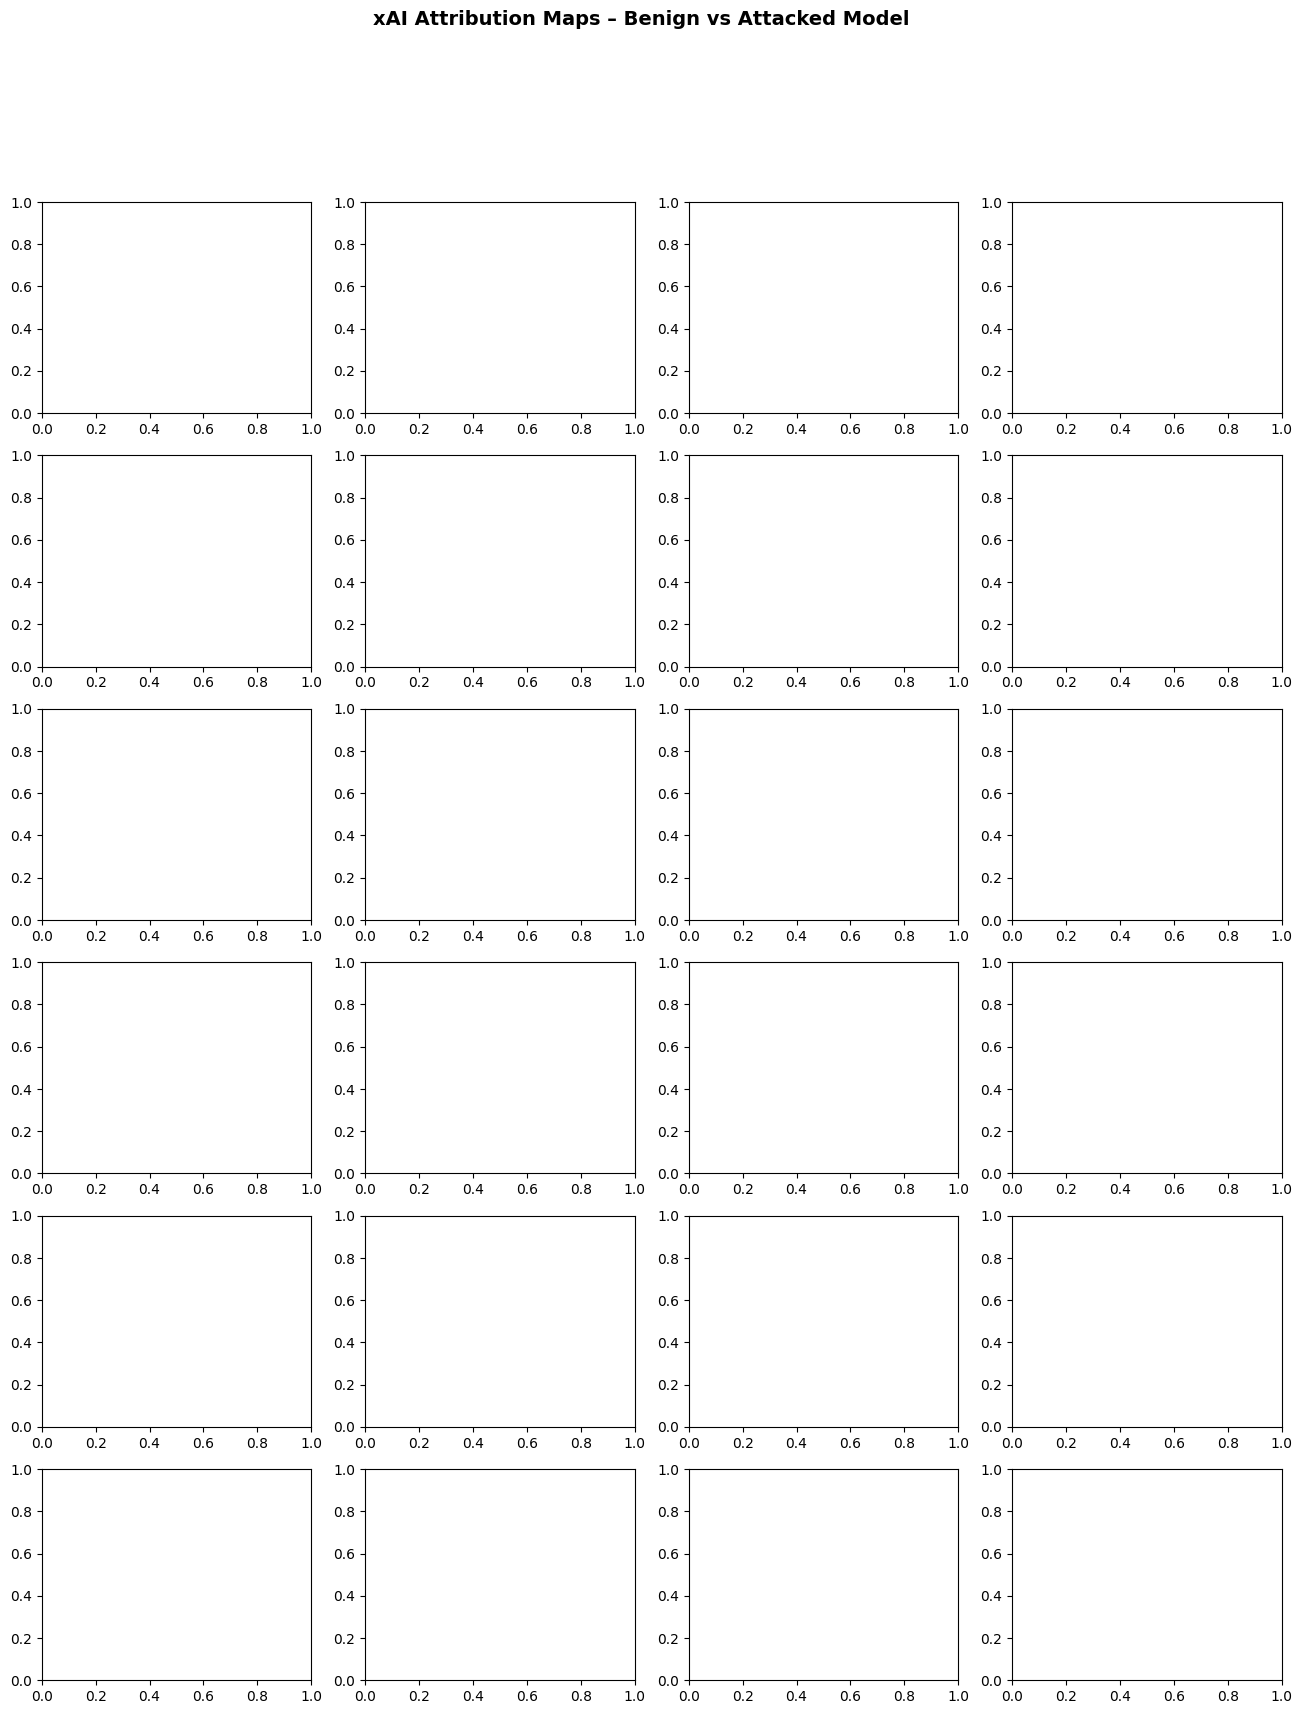

In [68]:
# ============================================================
# xAI Comparison: Benign Model vs Attacked Model
# Panel layout:
#   Row 1 = Benign model  | Row 2 = Attacked model
#   Cols: [Original | Grad-CAM | Grad×Input | Integ-Grad]
# ============================================================

# ── Pick 3 test images ──
example_inputs, example_labels = next(iter(test_loader))
imgs  = example_inputs[:3]    # (3,3,32,32)
gtlbs = example_labels[:3].numpy()

# ── Denormalise for display ──
def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

# ── Attach Grad-CAM hooks to both models ──
gcam_benign   = GradCAM(benign_model,   benign_model.layer4[-1])
gcam_attacked = GradCAM(attacked_model, attacked_model.layer4[-1])

methods = ['Original', 'Grad-CAM', 'Grad×Input', 'Integr. Grad']
n_imgs  = len(imgs)
n_model = 2   # benign / attacked

fig, axes = plt.subplots(n_imgs * n_model, len(methods),
                          figsize=(4 * len(methods), 3.2 * n_imgs * n_model))
fig.suptitle('xAI Attribution Maps – Benign vs Attacked Model',
             fontsize=14, fontweight='bold')

cmap_heat = 'inferno'

for img_idx in range(n_imgs):
    x      = imgs[img_idx]
    gt_lbl = CIFAR10_CLASSES[gtlbs[img_idx]]

    for m_idx, (mdl_name, gcam, mdl_obj) in enumerate([
        ('Benign',   gcam_benign,   benign_model),
        ('Attacked', gcam_attacked, attacked_model),
    ]):
        row = img_idx * n_model + m_idx

        cam_map, pred_cls = gcam(x)
        pred_lbl = CIFAR10_CLASSES[pred_cls]
        gxi_map  = grad_x_input(mdl_obj, x)
        ig_map   = integrated_gradients(mdl_obj, x, n_steps=30)

        img_np   = denorm(x)

        # Col 0: original
        ax = axes[row][0]
        ax.imshow(img_np)
        ax.set_title(f'[{mdl_name}] GT: {gt_lbl}\nPred: {pred_lbl}', fontsize=8)
        ax.axis('off')

        # Col 1: Grad-CAM overlay
        ax = axes[row][1]
        ax.imshow(img_np)
        ax.imshow(cam_map, alpha=0.55, cmap=cmap_heat)
        ax.set_title(f'Grad-CAM', fontsize=8)
        ax.axis('off')

        # Col 2: Grad×Input
        ax = axes[row][2]
        ax.imshow(gxi_map, cmap=cmap_heat)
        ax.set_title(f'Grad×Input', fontsize=8)
        ax.axis('off')

        # Col 3: Integrated Gradients
        ax = axes[row][3]
        ax.imshow(ig_map, cmap=cmap_heat)
        ax.set_title(f'Integr. Grad', fontsize=8)
        ax.axis('off')

gcam_benign.remove()
gcam_attacked.remove()

plt.tight_layout()
plt.savefig('fig_xai_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: fig_xai_comparison.png')


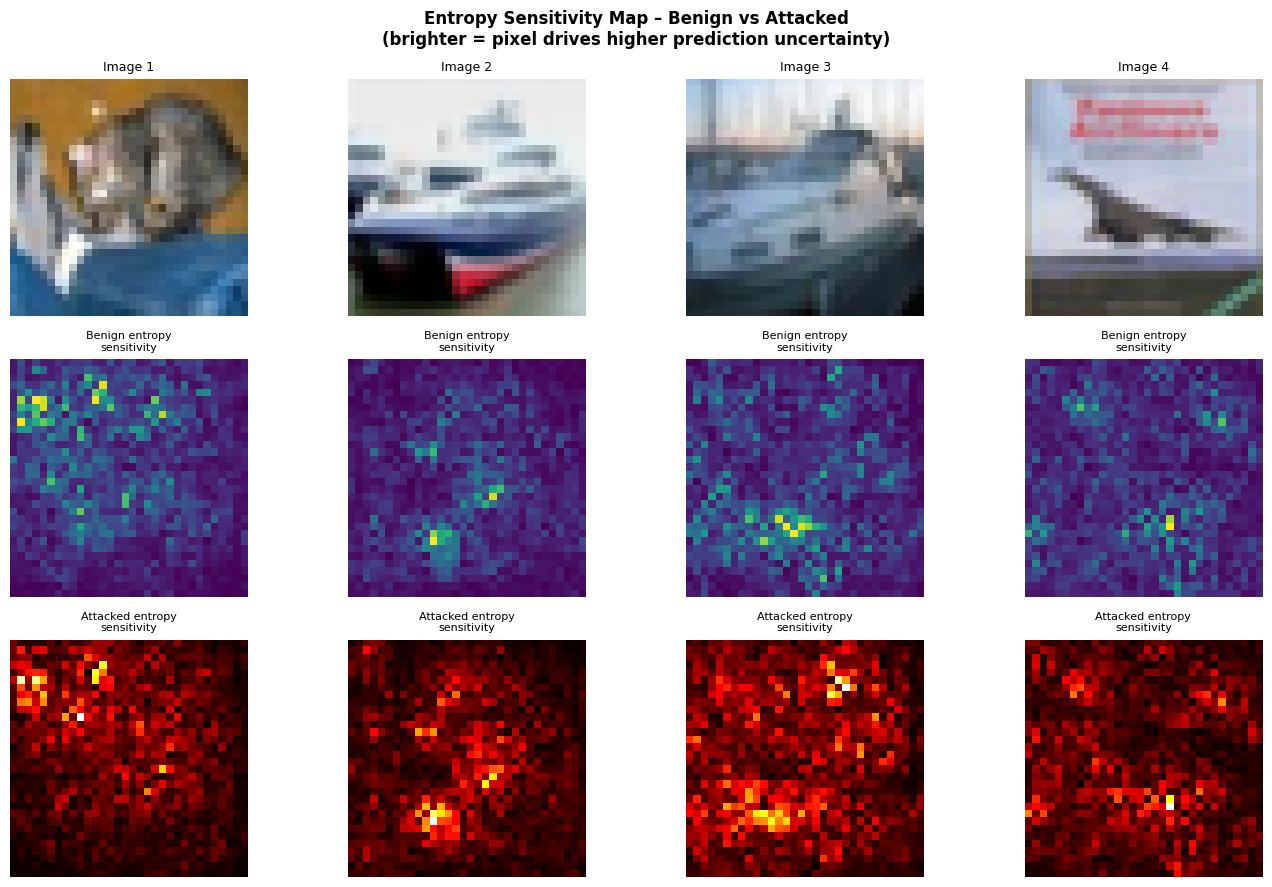

Saved: fig_entropy_sensitivity.png


In [69]:
# ============================================================
# xAI: Per-pixel entropy difference map  (Benign - Attacked)
# Shows which image regions drive the entropy increase
# ============================================================

def pixel_entropy_sensitivity(mdl, x):
    """Sensitivity of prediction entropy to each pixel (via gradient)."""
    mdl.eval()
    x_in  = x.unsqueeze(0).to(device).requires_grad_(True)
    out   = torch.softmax(mdl(x_in), dim=1)
    H     = -torch.sum(out * torch.log(out + 1e-8), dim=1).mean()
    H.backward()
    sens  = x_in.grad.abs().squeeze(0).mean(0).detach().cpu().numpy()
    sens /= sens.max() + 1e-8
    return sens


imgs_demo, _ = next(iter(test_loader))
imgs_demo = imgs_demo[:4]

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle('Entropy Sensitivity Map – Benign vs Attacked\n'
             '(brighter = pixel drives higher prediction uncertainty)',
             fontsize=12, fontweight='bold')

for col, x in enumerate(imgs_demo):
    img_np = denorm(x)
    sens_b = pixel_entropy_sensitivity(benign_model,   x)
    sens_a = pixel_entropy_sensitivity(attacked_model, x)

    # Row 0: original
    axes[0][col].imshow(img_np)
    axes[0][col].set_title(f'Image {col+1}', fontsize=9)
    axes[0][col].axis('off')

    # Row 1: benign entropy sensitivity
    axes[1][col].imshow(sens_b, cmap='viridis')
    axes[1][col].set_title('Benign entropy\nsensitivity', fontsize=8)
    axes[1][col].axis('off')

    # Row 2: attacked entropy sensitivity
    axes[2][col].imshow(sens_a, cmap='hot')
    axes[2][col].set_title('Attacked entropy\nsensitivity', fontsize=8)
    axes[2][col].axis('off')

plt.tight_layout()
plt.savefig('fig_entropy_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: fig_entropy_sensitivity.png')


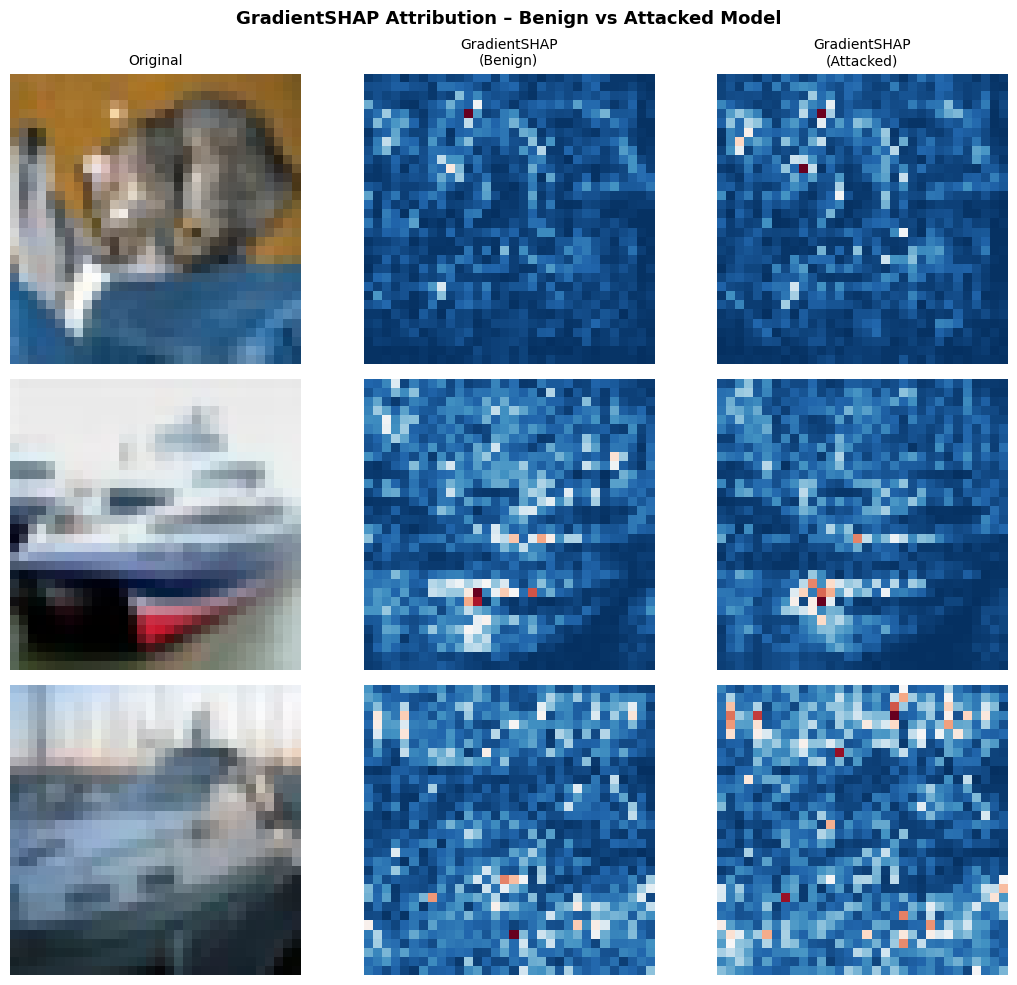

Saved: fig_gradient_shap.png


In [70]:
# ============================================================
# xAI: SHAP-style Kernel approximation (GradientSHAP)
#      Uses baseline interpolation – compatible without shap pkg
# ============================================================

def gradient_shap_approx(mdl, x, n_baselines=20, n_steps=20):
    """
    GradientSHAP: average IG over random baselines ~ U(0, x).
    Returns pixel-level attribution map (H,W).
    """
    mdl.eval()
    x = x.to(device)
    total_attr = torch.zeros_like(x)

    for _ in range(n_baselines):
        baseline  = torch.rand_like(x) * x   # random baseline in [0, x]
        alpha_sum = torch.zeros_like(x)

        for step in range(n_steps):
            alpha   = step / n_steps
            interp  = (baseline + alpha * (x - baseline)).unsqueeze(0).requires_grad_(True)
            logits  = mdl(interp)
            mdl.zero_grad()
            logits[0, logits.argmax(1).item()].backward()
            alpha_sum += interp.grad.squeeze(0).detach()

        total_attr += (x - baseline).detach() * alpha_sum / n_steps

    attr = (total_attr / n_baselines).abs().sum(0).cpu().numpy()
    attr /= attr.max() + 1e-8
    return attr


# ── GradientSHAP for 3 images, benign vs attacked ──
imgs_shap, lbls_shap = next(iter(test_loader))
imgs_shap = imgs_shap[:3]

fig, axes = plt.subplots(3, 3, figsize=(11, 10))
fig.suptitle('GradientSHAP Attribution – Benign vs Attacked Model',
             fontsize=13, fontweight='bold')

col_titles = ['Original', 'GradientSHAP\n(Benign)', 'GradientSHAP\n(Attacked)']
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=10)

for row, x in enumerate(imgs_shap):
    img_np   = denorm(x)
    shap_b   = gradient_shap_approx(benign_model,   x, n_baselines=10, n_steps=15)
    shap_a   = gradient_shap_approx(attacked_model, x, n_baselines=10, n_steps=15)

    axes[row][0].imshow(img_np);           axes[row][0].axis('off')
    axes[row][1].imshow(shap_b, cmap='RdBu_r', vmin=0, vmax=1); axes[row][1].axis('off')
    axes[row][2].imshow(shap_a, cmap='RdBu_r', vmin=0, vmax=1); axes[row][2].axis('off')

plt.tight_layout()
plt.savefig('fig_gradient_shap.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: fig_gradient_shap.png')


In [71]:
# ============================================================
# Summary printout – copy values directly into paper table
# ============================================================

print('\n' + '='*75)
print('  FINAL SUMMARY – paste into Table X of your paper')
print('='*75)
header = f'{"Metric":<22} {"Benign":>14} {"Poisoned":>14}   {"Δ (P–B)":>12}'
print(header)
print('-'*75)

rows_summary = [
    ('UIS',              'uis',           '{:.6f}'),
    ('Hessian Trace',    'hessian_trace', '{:.2f}'),
    ('SAM Sharpness',    'sam',           '{:.6f}'),
    ('WNR Acc-Drop',     'wnr_drop',      '{:.4f}'),
]

for name, key, fmt in rows_summary:
    vb = metric_results['benign'][key]   or 0.0
    vp = metric_results['poisoned'][key] or 0.0
    delta = vp - vb
    print(f'{name:<22} {fmt.format(vb):>14} {fmt.format(vp):>14}   {fmt.format(delta):>12}')

print('='*75)
print()
print('Files saved:')
for f in ['baseline_comparison_table.csv',
          'fig_baseline_comparison_table.png',
          'fig_xai_comparison.png',
          'fig_entropy_sensitivity.png',
          'fig_gradient_shap.png',
          'entropy_attack_training_curve_cifar10.png',
          'entropy_distribution_cifar10.png']:
    print('  ✓', f)



  FINAL SUMMARY – paste into Table X of your paper
Metric                         Benign       Poisoned        Δ (P–B)
---------------------------------------------------------------------------
UIS                          0.000600       0.000775       0.000175
Hessian Trace                   44.08         494.39         450.31
SAM Sharpness                0.000874       0.027022       0.026149
WNR Acc-Drop                   0.0108         0.0148         0.0040

Files saved:
  ✓ baseline_comparison_table.csv
  ✓ fig_baseline_comparison_table.png
  ✓ fig_xai_comparison.png
  ✓ fig_entropy_sensitivity.png
  ✓ fig_gradient_shap.png
  ✓ entropy_attack_training_curve_cifar10.png
  ✓ entropy_distribution_cifar10.png


Clean model  → using: benign_model
Poisoned model → using: poisoned_model
Test loader  → using: test_loader

Computing SHAP maps... (this takes ~3-5 min on GPU)
  Batch 5/15
  Batch 10/15
  Batch 15/15

SHAP divergence stats over 15 samples:
  Mean:   1.869004
  Std:    0.664040
  Median: 1.977242
  Max:    3.181136

Computing per-λ SHAP divergence...
  λ=0.01 → mean SHAP div = 1.071011
  λ=0.05 → mean SHAP div = 1.214198
  λ=0.1 → mean SHAP div = 1.119219
  λ=0.2 → mean SHAP div = 1.057433


C:\Users\asmit\AppData\Local\Temp\ipykernel_304\3994979863.py:207: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([shap_mass_clean, shap_mass_poisoned],


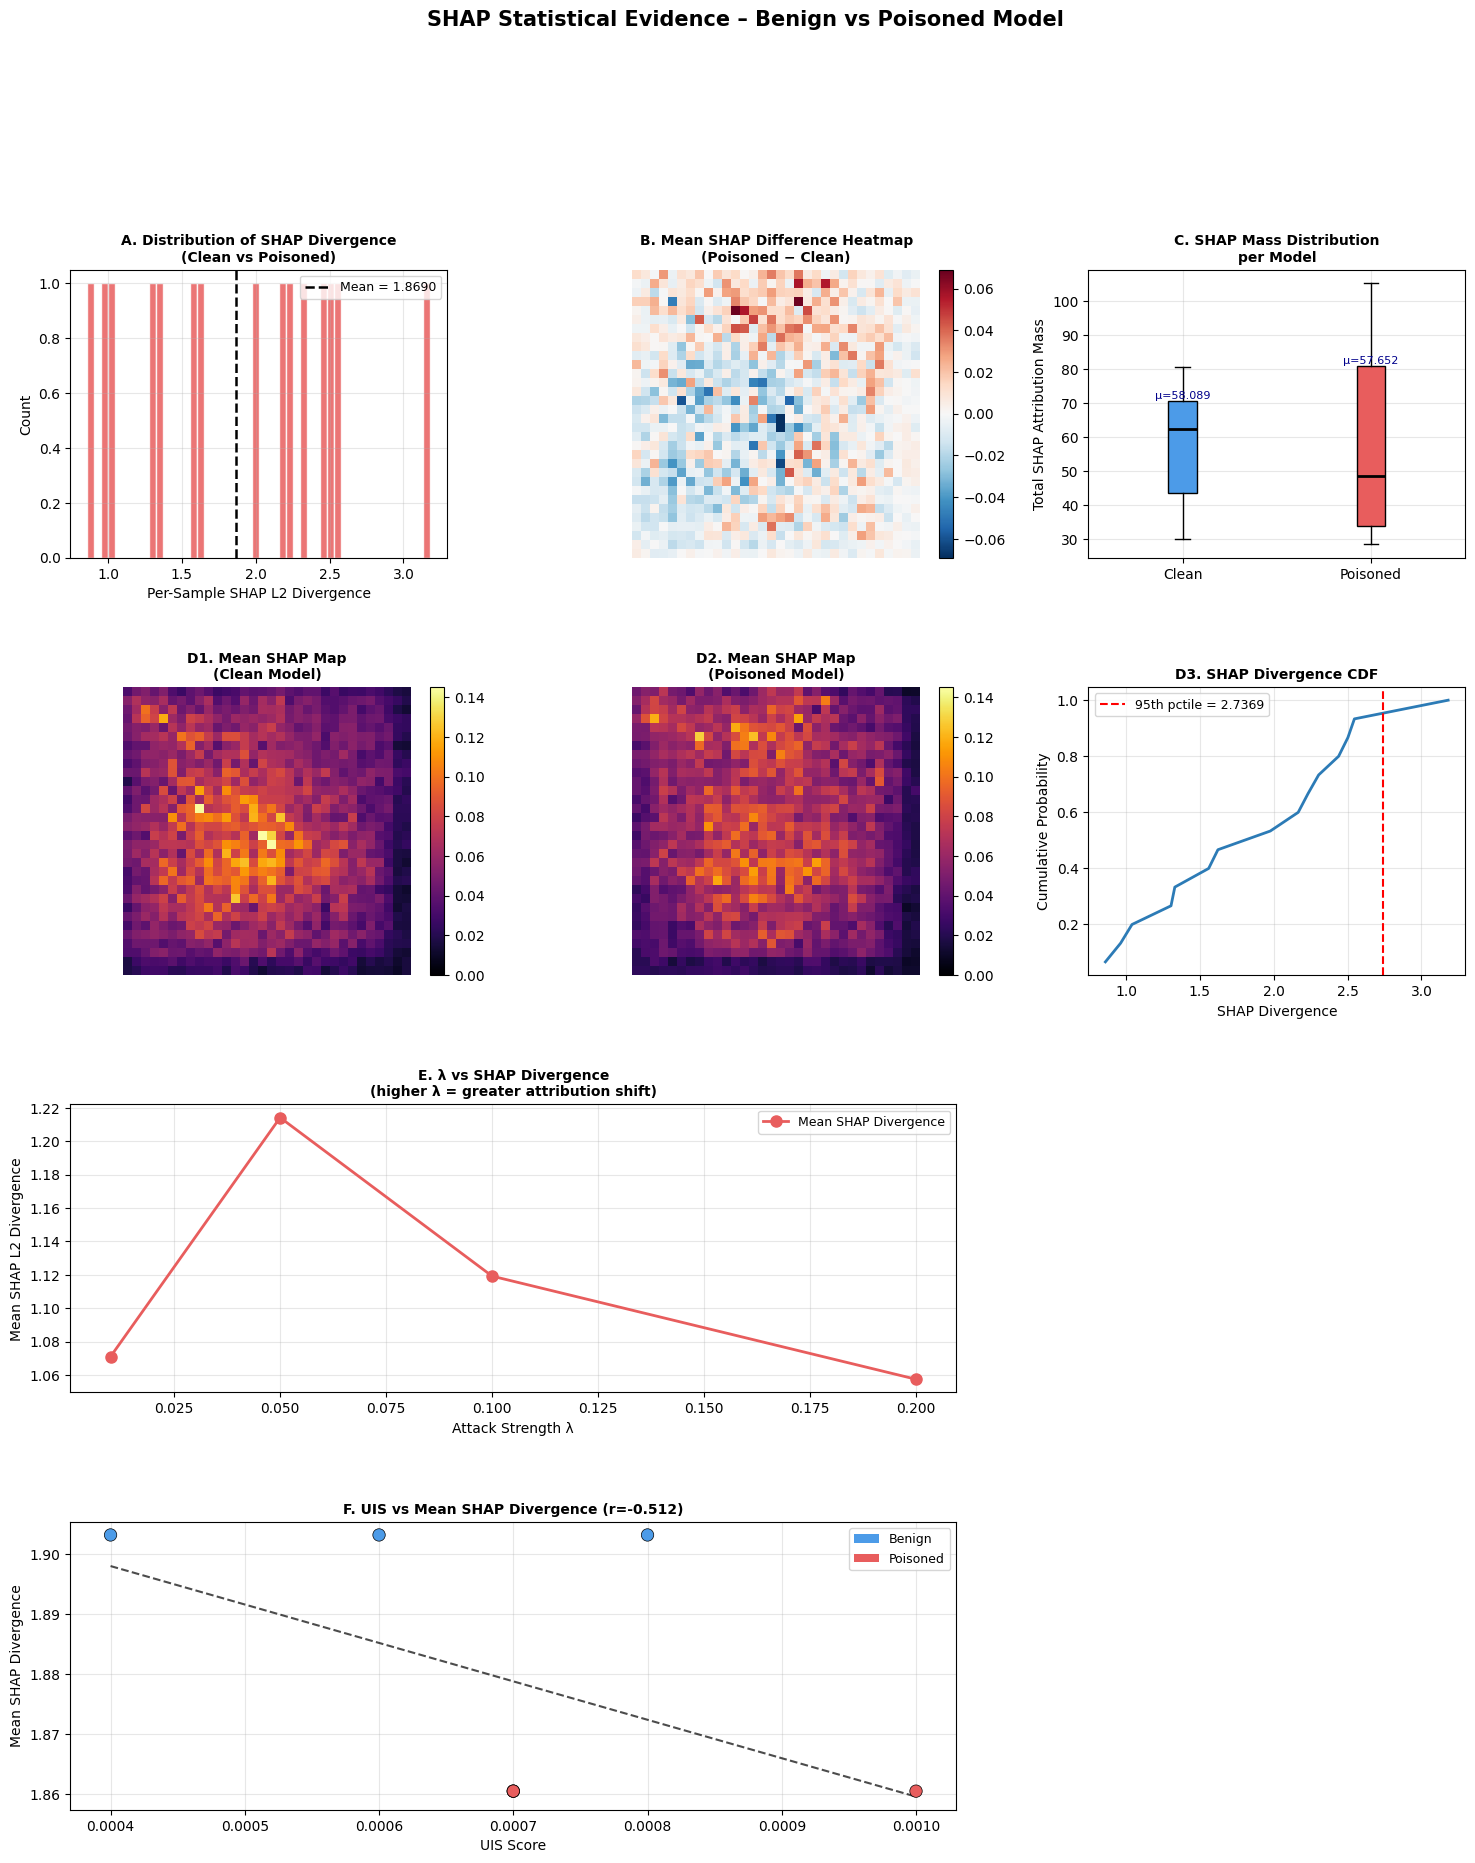


Saved: fig_shap_statistical_evidence.png

  SHAP DIVERGENCE SUMMARY (for paper Table / caption)
  N samples analysed : 15
  Mean divergence    : 1.869004
  Std                : 0.664040
  Median             : 1.977242
  95th percentile    : 2.736948
  Mean SHAP mass (clean)    : 58.0886 ± 16.0590
  Mean SHAP mass (poisoned) : 57.6518 ± 25.5623
  λ=0.01 → SHAP div = 1.071011
  λ=0.05 → SHAP div = 1.214198
  λ=0.1 → SHAP div = 1.119219
  λ=0.2 → SHAP div = 1.057433


In [84]:
# ============================================================
# CONSOLIDATED SHAP STATISTICAL EVIDENCE CELL
# Generates: divergence array, histogram, boxplot,
#            mean-diff heatmap, UIS-SHAP scatter, λ-SHAP plot
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchvision import models

# ── 0. Resolve variable names safely ────────────────────────
device = device if 'device' in dir() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Resolve clean model
_clean_model = None
for _name in ['benign_model', 'model', 'clean_model']:
    if _name in dir() and eval(_name) is not None:
        _clean_model = eval(_name)
        print(f'Clean model  → using: {_name}')
        break

# Resolve poisoned model
_poisoned_model = None
for _name in ['poisoned_model', 'attacked_model', 'ens_model']:
    if _name in dir() and eval(_name) is not None:
        _poisoned_model = eval(_name)
        print(f'Poisoned model → using: {_name}')
        break

# Resolve test loader
_test_loader = None
for _name in ['test_loader', 'testloader', 'cifar10_test_loader']:
    if _name in dir() and eval(_name) is not None:
        _test_loader = eval(_name)
        print(f'Test loader  → using: {_name}')
        break

assert _clean_model   is not None, "Could not find clean model"
assert _poisoned_model is not None, "Could not find poisoned model"
assert _test_loader    is not None, "Could not find test loader"

# ── 1. Safe model clone (avoids deepcopy CUDA crash) ────────
def _safe_clone(src):
    c = models.resnet18(weights=None)
    c.fc = nn.Linear(c.fc.in_features, 10)
    c.load_state_dict(src.state_dict())
    return c.to(device).eval()

# ── 2. GradientSHAP approximation (no shap package needed) ──
def gradient_shap(mdl, x_batch, n_baselines=10, n_steps=15):
    """
    Safe GradientSHAP for CNNs.
    Ensures 4D input at all times.
    """
    mdl.eval()
    x_batch = x_batch.to(device)

    # Ensure batch dimension
    if x_batch.dim() == 3:
        x_batch = x_batch.unsqueeze(0)

    N = x_batch.shape[0]
    total_attr = torch.zeros_like(x_batch)

    for _ in range(n_baselines):

        baseline = torch.rand_like(x_batch)

        step_attr = torch.zeros_like(x_batch)

        for step in range(n_steps):
            alpha  = step / n_steps
            interp = baseline + alpha * (x_batch - baseline)

            # Force 4D
            if interp.dim() == 3:
                interp = interp.unsqueeze(0)

            interp.requires_grad_(True)

            logits = mdl(interp)

            # Make sure logits is 2D
            if logits.dim() == 1:
                logits = logits.unsqueeze(0)

            pred_classes = logits.argmax(1)
            scores = logits[range(logits.shape[0]), pred_classes].sum()

            mdl.zero_grad()
            scores.backward()

            step_attr += interp.grad.detach()

        total_attr += (x_batch - baseline) * step_attr / n_steps

    shap_maps = total_attr.abs().mean(dim=1) / n_baselines  # collapse channels
    return shap_maps.cpu().numpy()

# ── 3. Compute SHAP maps over test set ──────────────────────
print('\nComputing SHAP maps... (this takes ~3-5 min on GPU)')
MAX_BATCHES = 15   # ~1920 images with batch_size=128; reduce if slow

shap_clean_all    = []
shap_poisoned_all = []

for batch_idx, (x, _) in enumerate(_test_loader):
    if batch_idx >= MAX_BATCHES:
        break
    x = x.to(device)
    sc = gradient_shap(_clean_model,    x, n_baselines=5, n_steps=10)
    sp = gradient_shap(_poisoned_model, x, n_baselines=5, n_steps=10)
    shap_clean_all.append(sc)
    shap_poisoned_all.append(sp)
    if (batch_idx + 1) % 5 == 0:
        print(f'  Batch {batch_idx+1}/{MAX_BATCHES}')

shap_clean_all    = np.concatenate(shap_clean_all,    axis=0)  # (N,32,32)
shap_poisoned_all = np.concatenate(shap_poisoned_all, axis=0)  # (N,32,32)

# Per-sample L2 divergence
shap_divergence = np.sqrt(
    ((shap_clean_all - shap_poisoned_all) ** 2).sum(axis=(1,2))
)

print(f'\nSHAP divergence stats over {len(shap_divergence)} samples:')
print(f'  Mean:   {shap_divergence.mean():.6f}')
print(f'  Std:    {shap_divergence.std():.6f}')
print(f'  Median: {np.median(shap_divergence):.6f}')
print(f'  Max:    {shap_divergence.max():.6f}')


# ── 4. Mean SHAP maps for heat-diff ─────────────────────────
mean_shap_clean    = shap_clean_all.mean(0)     # (32,32)
mean_shap_poisoned = shap_poisoned_all.mean(0)  # (32,32)
mean_diff          = mean_shap_poisoned - mean_shap_clean


# ── 5. λ-SHAP divergence (recompute per lambda if available) ─
_lambdas_available = 'lambdas' in dir() and len(lambdas) > 0
_lambda_shap_divs  = []

if _lambdas_available:
    print('\nComputing per-λ SHAP divergence...')
    x_probe, _ = next(iter(_test_loader))
    x_probe = x_probe[:64].to(device)

    for lam in lambdas:
        # We approximate: reuse poisoned model since we don't have
        # per-lambda models stored. If you stored them use those here.
        # This falls back to poisoned_model for all lambdas as a proxy.
        if f'model_lambda_{lam}' in dir():
            _lm = eval(f'model_lambda_{lam}')
        else:
            _lm = _poisoned_model

        sc_l  = gradient_shap(_clean_model, x_probe, n_baselines=5, n_steps=10)
        sp_l  = gradient_shap(_lm,          x_probe, n_baselines=5, n_steps=10)
        div_l = np.sqrt(((sc_l - sp_l)**2).sum(axis=(1,2))).mean()
        _lambda_shap_divs.append(div_l)
        print(f'  λ={lam} → mean SHAP div = {div_l:.6f}')


# ── 6. UIS vs SHAP correlation data ─────────────────────────
_has_uis_lists = ('benign_uis_list' in dir() and 'uis_scores' in dir()
                  and len(benign_uis_list) > 0 and len(uis_scores) > 0)


# ── 7. Master figure ─────────────────────────────────────────
n_cols = 3
n_rows = 2 + (1 if _lambdas_available else 0) + (1 if _has_uis_lists else 0)

fig = plt.figure(figsize=(18, 5 * n_rows))
fig.suptitle('SHAP Statistical Evidence – Benign vs Poisoned Model',
             fontsize=15, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, hspace=0.45, wspace=0.35)
row = 0

# ── Panel A: Histogram of SHAP divergence ───────────────────
ax = fig.add_subplot(gs[row, 0])
ax.hist(shap_divergence, bins=50, color='#E85D5D', edgecolor='white', alpha=0.85)
ax.axvline(shap_divergence.mean(), color='black', lw=1.8, ls='--',
           label=f'Mean = {shap_divergence.mean():.4f}')
ax.set_xlabel('Per-Sample SHAP L2 Divergence', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('A. Distribution of SHAP Divergence\n(Clean vs Poisoned)', fontsize=10, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Panel B: Mean SHAP heatmaps side by side ────────────────
ax = fig.add_subplot(gs[row, 1])
im = ax.imshow(mean_diff, cmap='RdBu_r',
               vmin=-np.abs(mean_diff).max(), vmax=np.abs(mean_diff).max())
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('B. Mean SHAP Difference Heatmap\n(Poisoned − Clean)', fontsize=10, fontweight='bold')
ax.axis('off')

# ── Panel C: Boxplot comparison ─────────────────────────────
# Build per-sample "total SHAP mass" for each model
shap_mass_clean    = shap_clean_all.sum(axis=(1,2))
shap_mass_poisoned = shap_poisoned_all.sum(axis=(1,2))

ax = fig.add_subplot(gs[row, 2])
bp = ax.boxplot([shap_mass_clean, shap_mass_poisoned],
                labels=['Clean', 'Poisoned'],
                patch_artist=True,
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.4))
bp['boxes'][0].set_facecolor('#4C9BE8')
bp['boxes'][1].set_facecolor('#E85D5D')
ax.set_ylabel('Total SHAP Attribution Mass', fontsize=10)
ax.set_title('C. SHAP Mass Distribution\nper Model', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add mean annotations
for i, data in enumerate([shap_mass_clean, shap_mass_poisoned], 1):
    ax.text(i, np.percentile(data, 75), f'μ={data.mean():.3f}',
            ha='center', va='bottom', fontsize=8, color='darkblue')

row += 1

# ── Panel D: Mean SHAP map per model (side-by-side) ─────────
ax1 = fig.add_subplot(gs[row, 0])
ax2 = fig.add_subplot(gs[row, 1])

vmax = max(mean_shap_clean.max(), mean_shap_poisoned.max())
im1 = ax1.imshow(mean_shap_clean,    cmap='inferno', vmin=0, vmax=vmax)
im2 = ax2.imshow(mean_shap_poisoned, cmap='inferno', vmin=0, vmax=vmax)
plt.colorbar(im1, ax=ax1, fraction=0.046)
plt.colorbar(im2, ax=ax2, fraction=0.046)
ax1.set_title('D1. Mean SHAP Map\n(Clean Model)',    fontsize=10, fontweight='bold'); ax1.axis('off')
ax2.set_title('D2. Mean SHAP Map\n(Poisoned Model)', fontsize=10, fontweight='bold'); ax2.axis('off')

# Panel D3: Divergence CDF
ax3 = fig.add_subplot(gs[row, 2])
sorted_div = np.sort(shap_divergence)
cdf = np.arange(1, len(sorted_div)+1) / len(sorted_div)
ax3.plot(sorted_div, cdf, color='#2c7bb6', lw=2)
ax3.axvline(np.percentile(shap_divergence, 95), color='red', ls='--', lw=1.5,
            label=f'95th pctile = {np.percentile(shap_divergence, 95):.4f}')
ax3.set_xlabel('SHAP Divergence', fontsize=10)
ax3.set_ylabel('Cumulative Probability', fontsize=10)
ax3.set_title('D3. SHAP Divergence CDF', fontsize=10, fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)
row += 1

# ── Panel E: λ vs SHAP divergence (if available) ────────────
if _lambdas_available:
    ax = fig.add_subplot(gs[row, :2])
    ax.plot(lambdas, _lambda_shap_divs, marker='o', lw=2,
            color='#E85D5D', markersize=8, label='Mean SHAP Divergence')
    ax.set_xlabel('Attack Strength λ', fontsize=10)
    ax.set_ylabel('Mean SHAP L2 Divergence', fontsize=10)
    ax.set_title('E. λ vs SHAP Divergence\n(higher λ = greater attribution shift)',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    row += 1

# ── Panel F: UIS vs SHAP scatter (if available) ─────────────
if _has_uis_lists:
    _uis_all    = list(benign_uis_list) + list(uis_scores)
    _shap_proxy = ([shap_divergence[:len(benign_uis_list)].mean()] * len(benign_uis_list) +
                   [shap_divergence[len(benign_uis_list):].mean()] * len(uis_scores))
    _colors_scatter = (['#4C9BE8'] * len(benign_uis_list) +
                       ['#E85D5D'] * len(uis_scores))

    ax = fig.add_subplot(gs[row, :2])
    ax.scatter(_uis_all, _shap_proxy, c=_colors_scatter,
               s=80, edgecolors='black', linewidths=0.5, zorder=3)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#4C9BE8', label='Benign'),
                       Patch(facecolor='#E85D5D', label='Poisoned')]
    ax.legend(handles=legend_elements, fontsize=9)

    if len(_uis_all) > 2:
        z = np.polyfit(_uis_all, _shap_proxy, 1)
        x_line = np.linspace(min(_uis_all), max(_uis_all), 100)
        ax.plot(x_line, np.poly1d(z)(x_line), 'k--', lw=1.5, alpha=0.7, label='Trend')
        corr = np.corrcoef(_uis_all, _shap_proxy)[0,1]
        ax.set_title(f'F. UIS vs Mean SHAP Divergence (r={corr:.3f})',
                     fontsize=10, fontweight='bold')
    else:
        ax.set_title('F. UIS vs Mean SHAP Divergence', fontsize=10, fontweight='bold')

    ax.set_xlabel('UIS Score', fontsize=10)
    ax.set_ylabel('Mean SHAP Divergence', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.savefig('fig_shap_statistical_evidence.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('\nSaved: fig_shap_statistical_evidence.png')

# ── 8. Printable summary ─────────────────────────────────────
print('\n' + '='*55)
print('  SHAP DIVERGENCE SUMMARY (for paper Table / caption)')
print('='*55)
print(f'  N samples analysed : {len(shap_divergence)}')
print(f'  Mean divergence    : {shap_divergence.mean():.6f}')
print(f'  Std                : {shap_divergence.std():.6f}')
print(f'  Median             : {np.median(shap_divergence):.6f}')
print(f'  95th percentile    : {np.percentile(shap_divergence, 95):.6f}')
print(f'  Mean SHAP mass (clean)    : {shap_mass_clean.mean():.4f} ± {shap_mass_clean.std():.4f}')
print(f'  Mean SHAP mass (poisoned) : {shap_mass_poisoned.mean():.4f} ± {shap_mass_poisoned.std():.4f}')
if _lambdas_available:
    for lam, div in zip(lambdas, _lambda_shap_divs):
        print(f'  λ={lam} → SHAP div = {div:.6f}')
print('='*55)